In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import requests
from bs4 import BeautifulSoup
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')


✅ Libraries loaded successfully!


In [ ]:
stock_sector_map = {
    'AAPL': 'US Technology', 'NVDA': 'US Technology', 'META': 'US Technology',
    'AVGO': 'US Technology', 'GOOGL': 'US Technology',
    'JNJ': 'US Healthcare', 'ABBV': 'US Healthcare', 'LLY': 'US Healthcare',
    'JPM': 'US Financial', 'GS': 'US Financial', 'V': 'US Financial',
    'XOM': 'US Energy', 'MPC': 'US Energy',
    'CAT': 'US Consumer', 'WMT': 'US Consumer', 'COST': 'US Consumer', 'MCD': 'US Consumer',
    'DELTA.BK': 'Thai Stocks', 'ADVANC.BK': 'Thai Stocks', 'KBANK.BK': 'Thai Stocks',
    'PDD': 'Chinese Stocks', 'FUTU': 'Chinese Stocks',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
}
portfolio_tickers = list(stock_sector_map.keys())
print(f'หุ้นเดิมในพอร์ต: {len(portfolio_tickers)} ตัว')
print(f'กลุ่ม: {len(set(stock_sector_map.values()))} กลุ่ม')


หุ้นเดิมในพอร์ต: 30 ตัว
กลุ่ม: 10 กลุ่ม


In [ ]:
# === 3.1 S&P 500 — ดึงจาก Wikipedia ด้วย pd.read_html (robust กว่า BeautifulSoup) ===
print("📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...")
try:
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    resp = requests.get(url, headers=headers, timeout=30)
    from io import StringIO
    tables = pd.read_html(StringIO(resp.text))
    df_sp500 = tables[0]  # ตารางแรกคือ constituents

    # หา column ชื่อ Symbol/Ticker และ GICS Sector
    sym_col = [c for c in df_sp500.columns if 'Symbol' in str(c) or 'Ticker' in str(c)][0]
    sec_col = [c for c in df_sp500.columns if 'GICS Sector' in str(c)][0]

    sp500_tickers = df_sp500[sym_col].str.replace('.', '-', regex=False).tolist()
    sp500_sector_map = dict(zip(
        df_sp500[sym_col].str.replace('.', '-', regex=False),
        df_sp500[sec_col]
    ))

    print(f"  ✅ ได้ {len(sp500_tickers)} ตัว")
except Exception as e:
    print(f"  ❌ ไม่สามารถดึงข้อมูล S&P 500 ได้: {e}")
    sp500_tickers = []
    sp500_sector_map = {}

# === 3.2 SET (Thai Stocks) ===
print("\n📥 รายชื่อหุ้นไทย (SET)...")
thai_tickers_raw = [
    'ADVANC', 'AOT', 'AWC', 'BANPU', 'BBL', 'BDMS', 'BEM', 'BGRIM',
    'BH', 'BTS', 'CBG', 'CENTEL', 'COM7', 'CPALL', 'CPF', 'CPN',
    'CRC', 'DELTA', 'EA', 'EGCO', 'GLOBAL', 'GPSC', 'GULF', 'HMPRO',
    'IVL', 'JMART', 'JMT', 'KBANK', 'KCE', 'KTB', 'KTC',
    'LH', 'MINT', 'MTC', 'OR', 'OSP', 'PTT', 'PTTEP', 'PTTGC',
    'RATCH', 'SAWAD', 'SCB', 'SCC', 'SCGP', 'TISCO', 'TOP',
    'TRUE', 'TTB', 'TU', 'WHA',
    'BEAUTY', 'BCH', 'BCP', 'BJC', 'BLA',
    'GFPT', 'IRPC', 'ITD', 'MAJOR', 'MEGA', 'PLANB',
    'PSL', 'RS', 'SPALI', 'SYNEX',
    'TCAP', 'THANI', 'TPIPP', 'VGI',
]
thai_tickers = [t + '.BK' for t in thai_tickers_raw]
thai_sector_map = {t + '.BK': 'Thai Stocks' for t in thai_tickers_raw}
print(f"  ✅ ได้ {len(thai_tickers)} ตัว")

# === 3.3 Chinese ADRs ===
print("\n📥 รายชื่อหุ้นจีน (ADRs)...")
chinese_tickers = [
    'BABA', 'JD', 'PDD', 'BIDU', 'NIO', 'XPEV', 'LI', 'FUTU',
    'TME', 'BILI', 'IQ', 'ZTO', 'MNSO', 'VNET', 'DIDI',
    'TAL', 'EDU', 'NTES', 'WB', 'HTHT',
]
chinese_sector_map = {t: 'Chinese Stocks' for t in chinese_tickers}
print(f"  ✅ ได้ {len(chinese_tickers)} ตัว")

# === 3.4 ETFs ===
print("\n📥 รายชื่อ ETFs...")
etf_tickers = [
    'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'VCSH', 'EMLC', 'BND', 'AGG',
    'TIPS', 'MUB', 'BNDX',
    'GLD', 'SLV', 'COPX', 'USO', 'UNG', 'DBA', 'PDBC', 'GSG',
    'PPLT', 'PALL', 'CPER',
    'BTC-USD', 'ETH-USD',
    'EEM', 'VWO', 'EFA', 'VEA', 'MCHI', 'FXI', 'THD',
    'QQQ', 'SPY', 'IWM', 'VTI', 'DIA',
]
etf_sector_map = {
    'TLT': 'Bonds', 'IEF': 'Bonds', 'SHY': 'Bonds', 'LQD': 'Bonds',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds', 'BND': 'Bonds',
    'AGG': 'Bonds', 'TIPS': 'Bonds', 'MUB': 'Bonds', 'BNDX': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
    'USO': 'Commodities', 'UNG': 'Commodities', 'DBA': 'Commodities',
    'PDBC': 'Commodities', 'GSG': 'Commodities', 'PPLT': 'Commodities',
    'PALL': 'Commodities', 'CPER': 'Commodities',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'EEM': 'EM ETF', 'VWO': 'EM ETF', 'EFA': 'Intl ETF', 'VEA': 'Intl ETF',
    'MCHI': 'China ETF', 'FXI': 'China ETF', 'THD': 'Thai ETF',
    'QQQ': 'US ETF', 'SPY': 'US ETF', 'IWM': 'US ETF', 'VTI': 'US ETF', 'DIA': 'US ETF',
}
print(f"  ✅ ได้ {len(etf_tickers)} ตัว")

# === รวมทั้งหมด ===
all_tickers = list(set(sp500_tickers + thai_tickers + chinese_tickers + etf_tickers + portfolio_tickers))
all_tickers.sort()

all_sector_map = {}
all_sector_map.update(sp500_sector_map)
all_sector_map.update(thai_sector_map)
all_sector_map.update(chinese_sector_map)
all_sector_map.update(etf_sector_map)

print(f"\n🎯 รวมทั้งหมด: {len(all_tickers)} ตัว (หลังลบ duplicates)")


📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...
  ✅ ได้ 503 ตัว

📥 รายชื่อหุ้นไทย (SET)...
  ✅ ได้ 69 ตัว

📥 รายชื่อหุ้นจีน (ADRs)...
  ✅ ได้ 20 ตัว

📥 รายชื่อ ETFs...
  ✅ ได้ 37 ตัว

🎯 รวมทั้งหมด: 629 ตัว (หลังลบ duplicates)


In [ ]:
import os
import time
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

# สมมติว่ามีตัวแปร all_tickers ถูกประกาศไว้แล้วก่อนหน้านี้
# all_tickers = [...]

end_date = datetime.now()
start_date = end_date - timedelta(days=365*4)  # 4 ปีย้อนหลัง

print(f"ช่วงเวลา: {start_date.strftime('%Y-%m-%d')} ถึง {end_date.strftime('%Y-%m-%d')}")
print("⏳ กรุณารอสักครู่...\n")

batch_size = 50
all_data_list = []
tickers_to_download = []
all_data = pd.DataFrame()

# 1. ตรวจสอบไฟล์และหา Tickers ที่ต้องดาวน์โหลด
if os.path.exists('all_data.csv'):
    print("📂 พบไฟล์ all_data.csv อยู่แล้ว, กำลังโหลด...")
    all_data = pd.read_csv('all_data.csv', index_col=0, parse_dates=True)
    existing_tickers = set(all_data.columns)
    tickers_to_download = [t for t in all_tickers if t not in existing_tickers]
    
    if tickers_to_download:
        print(f"⚠️ พบ {len(tickers_to_download)} ตัวที่ยังไม่มีข้อมูลในไฟล์:")
        print(", ".join(tickers_to_download))
        print("⏳ กำลังดาวน์โหลดข้อมูลที่ขาดหาย...")
    else:
        print("✅ ข้อมูลครบถ้วนแล้ว ไม่มีตัวไหนขาดหาย")
else:        
    tickers_to_download = all_tickers
    print(f"กำลังดาวน์โหลดข้อมูลใหม่ทั้งหมด {len(tickers_to_download)} ตัว...")

# 2. วนลูปดาวน์โหลดเฉพาะ Tickers ที่ต้องการ
if tickers_to_download:
    for i in range(0, len(tickers_to_download), batch_size):
        batch = tickers_to_download[i:i+batch_size]
        batch_num = i // batch_size + 1
        total_batches = (len(tickers_to_download) + batch_size - 1) // batch_size
        print(f"  Batch {batch_num}/{total_batches}: downloading {len(batch)} tickers...", end=" ")
        
        try:
            batch_data = yf.download(batch, start=start_date, end=end_date, auto_adjust=True, threads=True)
            # Handle MultiIndex columns from yf.download
            if isinstance(batch_data.columns, pd.MultiIndex):
                batch_close = batch_data['Close']
            else:
                # Single ticker case
                batch_close = batch_data[['Close']].rename(columns={'Close': batch[0]})
            
            all_data_list.append(batch_close)
            n_cols = batch_close.shape[1] if isinstance(batch_close, pd.DataFrame) else 1
            print(f"✅ ได้ {n_cols} ตัว")
        except Exception as e:
            print(f"❌ Error: {e}")
        
        time.sleep(1)

# 3. นำข้อมูลใหม่มารวมกับข้อมูลเดิม (ตรวจสอบก่อน concat)
if all_data_list:
    new_data = pd.concat(all_data_list, axis=1)
    
    # ถ้ารวมกับไฟล์เดิมที่มีอยู่
    if not all_data.empty:
        all_data = pd.concat([all_data, new_data], axis=1)
    else:
        all_data = new_data
        
    all_data = all_data.loc[:, ~all_data.columns.duplicated()]
    all_data.to_csv('all_data.csv')
    print("💾 อัปเดตและบันทึกไฟล์ all_data.csv เรียบร้อยแล้ว")

print(f"\n📊 สรุปจำนวนข้อมูลทั้งหมด: {all_data.shape[1]} ตัว, {all_data.shape[0]} วัน")

ช่วงเวลา: 2022-04-08 ถึง 2026-04-07
⏳ กรุณารอสักครู่...

📂 พบไฟล์ all_data.csv อยู่แล้ว, กำลังโหลด...
✅ ข้อมูลครบถ้วนแล้ว ไม่มีตัวไหนขาดหาย

📊 สรุปจำนวนข้อมูลทั้งหมด: 629 ตัว, 1461 วัน


In [5]:
# กรองเฉพาะหุ้นที่มีข้อมูลเพียงพอ
# หมายเหตุ: Crypto (BTC, ETH) เทรดทุกวัน (~1460 วัน/4ปี)
# แต่หุ้นปกติเทรดแค่วันทำงาน (~1003 วัน/4ปี)
# ดังนั้นใช้ threshold ที่เหมาะสมกว่า: ≥750 วัน (ประมาณ 3 ปีของวันทำงาน)
min_data_days = 750

valid_cols = [col for col in all_data.columns if int(all_data[col].notna().sum()) >= min_data_days]
data_filtered = all_data[valid_cols].ffill().bfill()
data_filtered = data_filtered.dropna(how='all')

print(f"หุ้นที่มีข้อมูลเพียงพอ (≥{min_data_days} วัน): {len(valid_cols)} ตัว")
print(f"หลังลบ NaN rows: {data_filtered.shape[0]} วัน x {data_filtered.shape[1]} ตัว")

portfolio_in_data = [t for t in portfolio_tickers if t in data_filtered.columns]
portfolio_missing = [t for t in portfolio_tickers if t not in data_filtered.columns]
print(f"\nหุ้นเดิมที่มีข้อมูล: {len(portfolio_in_data)}/{len(portfolio_tickers)} ตัว")
if portfolio_missing:
    print(f"⚠️ หุ้นเดิมที่ขาด: {portfolio_missing}")
    
if len(data_filtered.columns) == 0:
    print("❌ ไม่มีหุ้นตัวไหนผ่านเกณฑ์ข้อมูล")


หุ้นที่มีข้อมูลเพียงพอ (≥750 วัน): 621 ตัว
หลังลบ NaN rows: 1461 วัน x 621 ตัว

หุ้นเดิมที่มีข้อมูล: 30/30 ตัว


In [9]:
# Currency Conversion: All Prices to THB
print("Downloading USD/THB exchange rate...")
try:
    usdthb_raw = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)
    if isinstance(usdthb_raw.columns, pd.MultiIndex):
        usdthb = usdthb_raw['Close'].iloc[:, 0]
    else:
        usdthb = usdthb_raw['Close']
    usdthb = usdthb.reindex(data_filtered.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min()):.2f} - {float(usdthb.max()):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data_filtered.index)

data_thb = data_filtered.copy()
thai_cols = [t for t in data_filtered.columns if t.endswith(".BK")]
usd_cols = [t for t in data_filtered.columns if not t.endswith(".BK")]

for ticker in usd_cols:
    data_thb[ticker] = data_filtered[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_cols)} USD assets to THB")
print(f"Thai assets ({len(thai_cols)}): already in THB")

data = data_thb


[*********************100%***********************]  1 of 1 completed

  USD/THB range: 30.91 - 38.30

Converted 553 USD assets to THB
Thai assets (68): already in THB


In [10]:
from pathlib import Path
import json

CONFIG_DIR = Path('config')
SETTINGS_PATH = CONFIG_DIR / 'settings.json'
ASSETS_PATH = CONFIG_DIR / 'assets.csv'

with SETTINGS_PATH.open() as f:
    settings = json.load(f)

BASE_CURRENCY = settings.get('base_currency', 'THB')
RANDOM_SEED = settings.get('random_seed', 42)
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

DATA_CFG = settings.get('data', {})
start_date = datetime.fromisoformat(DATA_CFG['start_date']) if DATA_CFG.get('start_date') else datetime.now() - timedelta(days=365 * 4)
end_date = datetime.fromisoformat(DATA_CFG['end_date']) if DATA_CFG.get('end_date') else datetime.now()

portfolio_cfg = settings.get('portfolio', {})
PORTFOLIO_VALUE = portfolio_cfg.get('value', 1_000_000)

currency_cfg = settings.get('currency', {})
FX_TICKERS = currency_cfg.get('fx_pairs', {})

quality_cfg = settings.get('quality_checks', {})
MAX_ABS_DAILY_RETURN = quality_cfg.get('max_abs_daily_return', 0.25)
MAX_ANNUAL_RETURN = quality_cfg.get('max_annual_return', 1.5)

mc_cfg = settings.get('monte_carlo', {})
NUM_MONTE_CARLO = mc_cfg.get('num_portfolios', 5000)

settings


{'base_currency': 'THB',
 'random_seed': 42,
 'data': {'start_date': '2022-03-21', 'end_date': '2026-03-20'},
 'risk_free_rate': {'ticker': '^TNX', 'fallback': 0.045},
 'portfolio': {'value': 1000000},
 'currency': {'fx_pairs': {'USD': 'USDTHB=X'}},
 'quality_checks': {'max_abs_daily_return': 0.25, 'max_annual_return': 1.5},
 'monte_carlo': {'num_portfolios': 5000}}

In [22]:
# ==========================================================
# Risk-Free Rate (Rf) for Sharpe Ratio
# ==========================================================
# Sharpe Ratio = (E(Rp) - Rf) / sigma_p
# Using US 10-Year Treasury Rate as proxy

import yfinance as yf

try:
    # Download US 10Y Treasury yield
    tnx = yf.download("^TNX", period="3mo", auto_adjust=True)["Close"]
    RISK_FREE_RATE = float(tnx['^TNX'].iloc[-1]) / 100  # convert from % to decimal
except:
    RISK_FREE_RATE = 0.045  # fallback: 4.5%

print("=" * 60)
print("Risk-Free Rate Configuration")
print("=" * 60)
print(f"  Rf (annual) = {RISK_FREE_RATE*100:.2f}%  (US 10Y Treasury)")  # ดอกเบี้ยแบบรายปี -> พันธบัตรรัฐบาลสหรัฐอเมริกาอายุ 10 ปี
print(f"  Rf (daily)  = {RISK_FREE_RATE/252*100:.4f}%") # ดอกเบี้ยผลตอบแทนตกแบบรายวัน
print()
print("  Sharpe Ratio formula:")
print("    SR = (E(Rp) - Rf) / sigma_p")
print(f"    (previously used Rf=0, now Rf={RISK_FREE_RATE*100:.2f}%)")


[*********************100%***********************]  1 of 1 completed

Risk-Free Rate Configuration
  Rf (annual) = 4.34%  (US 10Y Treasury)
  Rf (daily)  = 0.0172%

  Sharpe Ratio formula:
    SR = (E(Rp) - Rf) / sigma_p
    (previously used Rf=0, now Rf=4.34%)


In [ ]:
returns = data.pct_change().dropna()

if not returns.empty:
    annual_returns = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)
    sharpe_ratios = annual_returns / annual_volatility
    
    all_summary = pd.DataFrame({
        'Sector': [all_sector_map.get(t, 'Unknown') for t in returns.columns],
        'Annual Return (%)': (annual_returns * 100).round(2),
        'Annual Vol (%)': (annual_volatility * 100).round(2),
        'Sharpe Ratio': sharpe_ratios.round(3),
    })
    
    print(f"คำนวณสถิติได้: {len(all_summary)} ตัว")
    print(f"\nTop 50 Sharpe Ratio (ทุกตลาด):")
    print("=" * 70)
    display(all_summary.sort_values('Sharpe Ratio', ascending=False).head(50))
else:
    print("ไม่มีข้อมูลสำหรับการคำนวณสถิติ")
    sharpe_ratios = pd.Series(dtype=float)


NameError: name 'selected_stocks' is not defined

In [11]:
portfolio_cols = [t for t in portfolio_in_data if t in returns.columns]

if len(portfolio_cols) > 0 and len(returns.columns) > 0:
    corr_all = returns.corr()
    new_tickers = [t for t in returns.columns if t not in portfolio_tickers]
    print(f"หุ้นใหม่ที่ไม่ได้อยู่ในพอร์ตเดิม: {len(new_tickers)} ตัว")

    results = []
    for ticker in new_tickers:
        if ticker not in corr_all.columns or ticker not in sharpe_ratios.index:
            continue
        
        valid_portfolio_cols = [c for c in portfolio_cols if c in corr_all.columns]
        if len(valid_portfolio_cols) == 0:
            continue
        
        avg_corr = corr_all.loc[ticker, valid_portfolio_cols].mean()
        max_corr = corr_all.loc[ticker, valid_portfolio_cols].max()
        min_corr = corr_all.loc[ticker, valid_portfolio_cols].min()
        sharpe = float(sharpe_ratios.loc[ticker])
        annual_ret = float(annual_returns.loc[ticker]) * 100
        annual_vol = float(annual_volatility.loc[ticker]) * 100
        sector = all_sector_map.get(ticker, 'Unknown')
        
        if pd.isna(sharpe) or pd.isna(avg_corr):
            continue
        
        results.append({
            'Ticker': ticker,
            'Sector': sector,
            'Annual Return (%)': round(annual_ret, 2),
            'Annual Vol (%)': round(annual_vol, 2),
            'Sharpe': round(sharpe, 3),
            'Avg Corr (vs Portfolio)': round(float(avg_corr), 3),
            'Max Corr': round(float(max_corr), 3),
            'Min Corr': round(float(min_corr), 3),
        })

    if results:
        candidates_df = pd.DataFrame(results)
        good_candidates = candidates_df[candidates_df['Sharpe'] > 0.5].copy()
        
        if not good_candidates.empty:
            good_candidates['Diversification Score'] = (
                good_candidates['Sharpe'] * (1 - good_candidates['Avg Corr (vs Portfolio)'])
            ).round(3)
            good_candidates = good_candidates.sort_values('Diversification Score', ascending=False)

            print(f"\nหุ้นใหม่ที่ผ่านเกณฑ์ (Sharpe > 0.5): {len(good_candidates)} ตัว")

            # === Stratified Top 30: ให้ครบทุก 10 กลุ่ม (Sector) ===
            target_sectors = [
                'Bonds', 'Chinese Stocks', 'Commodities', 'Crypto', 'Thai Stocks',
                'US Consumer', 'US Energy', 'US Financial', 'US Healthcare', 'US Technology'
            ]
            TOP_N = 30
            MIN_PER_SECTOR = 3  # เลือกอย่างน้อย 3 ตัวต่อกลุ่ม

            selected = pd.DataFrame()
            remaining = good_candidates.copy()

            # ขั้นที่ 1: เลือกหุ้นดีสุดจากแต่ละกลุ่ม (Sector) อย่างน้อย MIN_PER_SECTOR ตัว
            for sector in target_sectors:
                sector_stocks = remaining[remaining['Sector'] == sector]
                if not sector_stocks.empty:
                    take_n = min(MIN_PER_SECTOR, len(sector_stocks))
                    top_sector = sector_stocks.head(take_n)
                    selected = pd.concat([selected, top_sector])
                    remaining = remaining[~remaining['Ticker'].isin(top_sector['Ticker'])]

            # ขั้นที่ 2: เติมที่เหลือด้วยหุ้นที่มี Diversification Score สูงสุด
            slots_left = TOP_N - len(selected)
            if slots_left > 0 and not remaining.empty:
                fill = remaining.head(slots_left)
                selected = pd.concat([selected, fill])

            # จัดเรียงตาม Diversification Score
            selected = selected.sort_values('Diversification Score', ascending=False)

            # แสดงสรุปจำนวนหุ้นในแต่ละกลุ่ม
            print("\n" + "=" * 100)
            print("🏆 Top 30 หุ้นที่เหมาะกับพอร์ตมากที่สุด (Diversification Score สูงสุด)")
            print("   ✅ คัดเลือกแบบ Stratified: มีตัวแทนจากทุก 10 กลุ่ม (Sector)")
            print("=" * 100)
            print("   Diversification Score = Sharpe × (1 - Avg Corr)")

            print("\n📊 สรุปจำนวนหุ้นในแต่ละกลุ่ม:")
            sector_counts = selected.groupby('Sector').size().reset_index(name='จำนวน')
            for _, row in sector_counts.iterrows():
                print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
            print(f"   {'─' * 30}")
            print(f"   รวมทั้งหมด: {len(selected)} ตัว\n")

            display(selected.set_index('Ticker'))
        else:
            print("\n❌ ไม่มีหุ้นใหม่ที่มี Sharpe > 0.5")
            good_candidates = pd.DataFrame()
    else:
        print("\n❌ ไม่มีหุ้นใหม่ที่สามารถคำนวณหา Correlation ได้ (อาจจะข้อมูลไม่พอ)")
        good_candidates = pd.DataFrame()
else:
    print("\n❌ ไม่มีข้อมูลหุ้นเพียงพอในการเปรียบเทียบ")
    good_candidates = pd.DataFrame()


หุ้นใหม่ที่ไม่ได้อยู่ในพอร์ตเดิม: 591 ตัว

หุ้นใหม่ที่ผ่านเกณฑ์ (Sharpe > 0.5): 122 ตัว

🏆 Top 30 หุ้นที่เหมาะกับพอร์ตมากที่สุด (Diversification Score สูงสุด)
   ✅ คัดเลือกแบบ Stratified: มีตัวแทนจากทุก 10 กลุ่ม (Sector)
   Diversification Score = Sharpe × (1 - Avg Corr)

📊 สรุปจำนวนหุ้นในแต่ละกลุ่ม:
   • Bonds               : 1 ตัว
   • Chinese Stocks      : 2 ตัว
   • Commodities         : 1 ตัว
   • Communication Services: 1 ตัว
   • Consumer Discretionary: 1 ตัว
   • Financials          : 2 ตัว
   • Health Care         : 2 ตัว
   • Industrials         : 6 ตัว
   • Information Technology: 6 ตัว
   • Thai Stocks         : 5 ตัว
   • Utilities           : 3 ตัว
   ──────────────────────────────
   รวมทั้งหมด: 30 ตัว



,Sector,Annual Return (%),Annual Vol (%),Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
TIPS,Bonds,428.49,352.69,1.215,0.014,0.064,-0.020,1.198
KTB.BK,Thai Stocks,21.71,18.74,1.158,0.009,0.473,-0.073,1.148
FIX,Industrials,54.82,39.70,1.381,0.263,0.519,-0.031,1.018
TISCO.BK,Thai Stocks,8.23,8.47,0.971,0.016,0.314,-0.073,0.955
CAH,Health Care,25.84,21.75,1.188,0.214,0.399,-0.093,0.934
EME,Industrials,36.72,29.54,1.243,0.280,0.541,-0.036,0.895
HWM,Industrials,35.44,27.05,1.310,0.323,0.559,-0.056,0.887
TTB.BK,Thai Stocks,15.33,17.08,0.898,0.026,0.364,-0.051,0.875
VRT,Industrials,62.79,53.00,1.185,0.274,0.630,-0.012,0.860


0.04310999870300293


tensor([[-0.0306, -0.0191, -0.0281,  ...,  0.0171, -0.0205, -0.0170],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0161, -0.0087,  0.0178,  ..., -0.0165,  0.0104,  0.0263],
        [ 0.0165,  0.0256,  0.0171,  ...,  0.0456,  0.0319,  0.0128],
        [-0.0094, -0.0094, -0.0094,  ..., -0.0094, -0.0094, -0.0094]],
       device='cuda:0')


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------
# Step 1 & 2: Data Cleaning & Heuristics (Keep as Pandas/NumPy)
# ---------------------------------------------------------
# Assuming 'close_data' is already defined in your environment


tickers = data.columns.tolist()
num_assets = len(tickers)
target_assets = 30

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

# ---------------------------------------------------------
# Step 3: PyTorch GPU Setup & Initialization
# ---------------------------------------------------------
# Automatically select GPU if available, else fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

# Move data to PyTorch Tensors on the GPU
returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)

# ACO Hyperparameters
num_ants = 200
num_iterations = 1000
alpha = 1.0
beta = 1.0
evaporation_rate = 0.1
Q = 1.0

# Pheromones live on the GPU
pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)

global_best_portfolio = None
global_best_fitness = -np.inf
global_best_sharpe = 0
convergence_curve = []

# Pre-calculate constant for annualization
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)

# ---------------------------------------------------------
# Step 4: Run the Vectorized ACO Algorithm
# ---------------------------------------------------------
for iteration in range(num_iterations):
    
    # 1. Calculate probabilities for all assets
    probabilities = (pheromones ** alpha) * (heuristic_tensor ** beta)
    probabilities /= probabilities.sum()
    
    # Expand probabilities so all ants can sample simultaneously
    # Shape: (num_ants, num_assets)
    probs_batch = probabilities.unsqueeze(0).expand(num_ants, -1)
    
    # 2. Vectorized Ant Selection (All 100 ants pick 30 assets at once)
    # Shape: (num_ants, target_assets)
    selected_indices = torch.multinomial(probs_batch, target_assets, replacement=False)
    
    # 3. FAST Decorrelation Fitness Calculation (Batch Matrix Indexing)
    # Extract the pre-calculated correlation sub-matrices for all ants at once
    idx_row = selected_indices.unsqueeze(2) # Shape: (100, 30, 1)
    idx_col = selected_indices.unsqueeze(1) # Shape: (100, 1, 30)
    
    # Resulting shape: (100, 30, 30)
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    
    # The sum of the off-diagonal elements is the total sum minus the diagonal (which is always 1.0 * target_assets)
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    # 4. FAST Sharpe Calculation (Batch Matrix Multiplication)
    # Create a sparse mask to calculate daily returns for all portfolios at once
    mask = torch.zeros((num_ants, num_assets), device=device)
    mask.scatter_(1, selected_indices, 1.0 / target_assets)
    
    # Returns shape: (Days, Assets). Mask.T shape: (Assets, Ants)
    # Resulting portfolio_returns shape: (Days, Ants)
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Avoid division by zero
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 5. Combined Fitness
    fitnesses = (portfolio_sharpe * 0.5) + (decorrelation_fitness * 0.5)
    
    # 6. Find Iteration Best
    iter_best_idx = torch.argmax(fitnesses)
    iter_best_portfolio = selected_indices[iter_best_idx]
    iter_best_fitness = fitnesses[iter_best_idx].item()
    iter_best_sharpe = portfolio_sharpe[iter_best_idx].item()
    
    # Update global best
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = iter_best_portfolio.cpu().numpy() # Pull back to CPU for storage
        global_best_sharpe = iter_best_sharpe
        
    convergence_curve.append(global_best_fitness)
    
    # 7. Pheromone Update Phase
    pheromones *= (1 - evaporation_rate)
    pheromones[iter_best_portfolio] += Q * iter_best_fitness

# ---------------------------------------------------------
# Step 5: Output the Results
# ---------------------------------------------------------
best_tickers = [tickers[i] for i in global_best_portfolio]
best_avg_correlation = 1.0 - global_best_fitness

print("\n--- ACO Optimization Complete ---")
print(f"Best Portfolio Average Correlation: {best_avg_correlation:.4f}")
print(f"Best Portfolio Decorrelation Score (Fitness): {global_best_fitness:.4f}")
print(f"Incidental Sharpe Ratio of this Portfolio: {global_best_sharpe:.4f}")

print("\nTop 30 Selected Assets for Maximum Decorrelation:")
for i, ticker in enumerate(best_tickers, 1):
    print(f"{i}. {ticker}")

# Plot the convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='o', color='b')
plt.title('ACO Convergence: Portfolio Decorrelation Score over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Decorrelation Score (1 - Avg Correlation)')
plt.grid(True)
plt.show()


Executing on: cuda
--- ACO Optimization Complete ---
Best Portfolio Average Correlation: -0.4805
Best Portfolio Decorrelation Score (Fitness): 1.4805
Incidental Sharpe Ratio of this Portfolio: 2.0599
Top 30 Selected Assets for Maximum Decorrelation:
1. TIPS
2. CAH
3. TRUE.BK
4. WMT
5. TISCO.BK
6. DELTA.BK
7. WHA.BK
8. SATS
9. MCK
10. CBOE
11. LITE
12. TTB.BK
13. TCAP.BK
14. LLY
15. KR
16. PLTR
17. VRT
18. SCB.BK
19. GLD
20. TAL
21. T
22. ORLY
23. ADVANC.BK
24. KBANK.BK
25. FIX
26. CME
27. VST
28. SLV
29. SMCI
30. COR


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------
# Step 1 & 2: Data Cleaning & Heuristics (Keep as Pandas/NumPy)
# ---------------------------------------------------------
# Assuming 'close_data' is already defined in your environment


tickers = data.columns.tolist()
num_assets = len(tickers)
target_assets = 30

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

# ---------------------------------------------------------
# Step 3: PyTorch GPU Setup & Initialization
# ---------------------------------------------------------
# Automatically select GPU if available, else fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

# Move data to PyTorch Tensors on the GPU
returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)

# ACO Hyperparameters
num_ants = 200
num_iterations = 1000
alpha = 1.0
beta = 1.0
evaporation_rate = 0.1
Q = 1.0

# Pheromones live on the GPU
pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)

global_best_portfolio = None
global_best_fitness = -np.inf
global_best_sharpe = 0
convergence_curve = []

# Pre-calculate constant for annualization
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)

# ---------------------------------------------------------
# Step 4: Run the Vectorized ACO Algorithm
# ---------------------------------------------------------
for iteration in range(num_iterations):
    
    # 1. Calculate probabilities for all assets
    probabilities = (pheromones ** alpha) * (heuristic_tensor ** beta)
    probabilities /= probabilities.sum()
    
    # Expand probabilities so all ants can sample simultaneously
    # Shape: (num_ants, num_assets)
    probs_batch = probabilities.unsqueeze(0).expand(num_ants, -1)
    
    # 2. Vectorized Ant Selection (All 100 ants pick 30 assets at once)
    # Shape: (num_ants, target_assets)
    selected_indices = torch.multinomial(probs_batch, target_assets, replacement=False)
    
    # 3. FAST Decorrelation Fitness Calculation (Batch Matrix Indexing)
    # Extract the pre-calculated correlation sub-matrices for all ants at once
    idx_row = selected_indices.unsqueeze(2) # Shape: (100, 30, 1)
    idx_col = selected_indices.unsqueeze(1) # Shape: (100, 1, 30)
    
    # Resulting shape: (100, 30, 30)
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    
    # The sum of the off-diagonal elements is the total sum minus the diagonal (which is always 1.0 * target_assets)
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    # 4. FAST Sharpe Calculation (Batch Matrix Multiplication)
    # Create a sparse mask to calculate daily returns for all portfolios at once
    mask = torch.zeros((num_ants, num_assets), device=device)
    mask.scatter_(1, selected_indices, 1.0 / target_assets)
    
    # Returns shape: (Days, Assets). Mask.T shape: (Assets, Ants)
    # Resulting portfolio_returns shape: (Days, Ants)
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Avoid division by zero
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 5. Combined Fitness
    fitnesses = portfolio_sharpe* decorrelation_fitness
    
    # 6. Find Iteration Best
    iter_best_idx = torch.argmax(fitnesses)
    iter_best_portfolio = selected_indices[iter_best_idx]
    iter_best_fitness = fitnesses[iter_best_idx].item()
    iter_best_sharpe = portfolio_sharpe[iter_best_idx].item()
    
    # Update global best
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = iter_best_portfolio.cpu().numpy() # Pull back to CPU for storage
        global_best_sharpe = iter_best_sharpe
        
    convergence_curve.append(global_best_fitness)
    
    # 7. Pheromone Update Phase
    pheromones *= (1 - evaporation_rate)
    pheromones[iter_best_portfolio] += Q * iter_best_fitness

# ---------------------------------------------------------
# Step 5: Output the Results
# ---------------------------------------------------------
best_tickers = [tickers[i] for i in global_best_portfolio]
best_avg_correlation = 1.0 - global_best_fitness

print("\n--- ACO Optimization Complete ---")
print(f"Best Portfolio Average Correlation: {best_avg_correlation:.4f}")
print(f"Best Portfolio Decorrelation Score (Fitness): {global_best_fitness:.4f}")
print(f"Incidental Sharpe Ratio of this Portfolio: {global_best_sharpe:.4f}")

print("\nTop 30 Selected Assets for Maximum Decorrelation:")
for i, ticker in enumerate(best_tickers, 1):
    print(f"{i}. {ticker}")

# Plot the convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='o', color='b')
plt.title('ACO Convergence: Portfolio Decorrelation Score over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Decorrelation Score (1 - Avg Correlation)')
plt.grid(True)
plt.show()


Executing on: cuda
--- ACO Optimization Complete ---
Best Portfolio Average Correlation: -0.9021
Best Portfolio Decorrelation Score (Fitness): 1.9021
Incidental Sharpe Ratio of this Portfolio: 2.0842
Top 30 Selected Assets for Maximum Decorrelation:
1. TCAP.BK
2. CAH
3. KTB.BK
4. BH.BK
5. TIPS
6. SMCI
7. TAL
8. DELTA.BK
9. ADVANC.BK
10. TTB.BK
11. WMT
12. CBOE
13. WHA.BK
14. KBANK.BK
15. LITE
16. TRUE.BK
17. PLTR
18. GLD
19. LLY
20. PGR
21. FIX
22. BCP.BK
23. KR
24. PM
25. JNJ
26. EDU
27. EME
28. TISCO.BK
29. SATS
30. VRT


In [ ]:
unique_sectors


['EM ETF',
 'US ETF',
 'Thai Stocks',
 'Utilities',
 'Commodities',
 'Communication Services',
 'Industrials',
 'Materials',
 'Bonds',
 'Energy',
 'Chinese Stocks',
 'Health Care',
 'Consumer Discretionary',
 'Financials',
 'Consumer Staples',
 'China ETF',
 'Information Technology',
 'Thai ETF',
 'Real Estate',
 'Intl ETF',
 'Crypto']


In [43]:
num_sectors


21


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------
# Step 1 & 2: Data Cleaning & Heuristics 
# ---------------------------------------------------------
# Assuming 'returns' dataframe and 'data' dataframe exist
tickers = data.columns.tolist()
num_assets = len(tickers)
target_assets = 100  # INCREASED: Must be >= (number_of_unique_sectors * 3)


# --- NEW: Sector Mapping Setup ---
# Assuming you have a dictionary, list, or DataFrame column mapping tickers to sectors
# Example mock data based on your provided list:

# Fallback to 'Unknown' if not in dict
ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 

# Convert sectors to integer IDs for PyTorch
unique_sectors = list(set(ticker_sectors))
num_sectors = len(unique_sectors)
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

# ---------------------------------------------------------
# Step 3: PyTorch GPU Setup & Initialization
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)

# --- NEW: Move Sector Labels to GPU ---
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)

num_ants = 500
num_iterations = 1000
alpha = 1.0
beta = 2.0
evaporation_rate = 0.2
Q = 1.0

pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)

global_best_portfolio = None
global_best_fitness = -np.inf
global_best_sharpe = 0
convergence_curve = []

# Minimum required assets per sector constraint
min_per_sector = 3

# ---------------------------------------------------------
# Step 4: Run the Vectorized ACO Algorithm
# ---------------------------------------------------------
for iteration in range(num_iterations):
    
    probabilities = (pheromones ** alpha) * (heuristic_tensor ** beta)
    probabilities /= probabilities.sum()
    probs_batch = probabilities.unsqueeze(0).expand(num_ants, -1)
    
    # --- NEW: Constrained Selection Phase ---
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    
    # Phase 1: Force every ant to pick 'min_per_sector' from each sector
    for sector_idx in range(len(unique_sectors)):
        # Create a mask for the current sector
        sector_mask = (sector_labels == sector_idx).float()
        
        # Apply mask to probabilities (ants can only see this sector right now)
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        # [แก้ไขจุดที่เกิด Error] เพิ่มค่า Epsilon เล็กน้อยเพื่อป้องกันค่าความน่าจะเป็นกลายเป็น 0
        epsilon = 1e-8
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        # Check how many assets actually exist in this sector to avoid errors
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            # Sample exactly 'actual_req' assets from this sector
            selected_s = torch.multinomial(probs_sector, actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            
            # Zero out the probabilities of the selected assets so they aren't picked again
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    # Combine all mandatory selections. Shape: (num_ants, total_mandatory_assets)
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_ants, 0), dtype=torch.int64, device=device)

    # Phase 2: Free selection for the remaining slots
    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        # Sample the rest from whatever hasn't been picked yet
        selected_rem = torch.multinomial(probs_remaining, num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1)
    else:
        # If mandatory selections exceeded target_assets, trim it (warn user if this happens)
        selected_indices = selected_mandatory[:, :target_assets]
    # ----------------------------------------
    
    # 3. FAST Decorrelation Fitness Calculation
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    # 4. FAST Sharpe Calculation 
    mask = torch.zeros((num_ants, num_assets), device=device)
    mask.scatter_(1, selected_indices, 1.0 / target_assets)
    
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 5. Combined Fitness
    fitnesses = portfolio_sharpe * decorrelation_fitness
    
    # 6. Find Iteration Best
    iter_best_idx = torch.argmax(fitnesses)
    iter_best_portfolio = selected_indices[iter_best_idx]
    iter_best_fitness = fitnesses[iter_best_idx].item()
    iter_best_sharpe = portfolio_sharpe[iter_best_idx].item()
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = iter_best_portfolio.cpu().numpy() 
        global_best_sharpe = iter_best_sharpe
        
    convergence_curve.append(global_best_fitness)
    
    # 7. Pheromone Update Phase
    pheromones *= (1 - evaporation_rate)
    pheromones[iter_best_portfolio] += Q * iter_best_fitness

# ---------------------------------------------------------
# Step 5: Output the Results
# ---------------------------------------------------------
best_tickers = [tickers[i] for i in global_best_portfolio]
best_avg_correlation = 1.0 - global_best_fitness

print("\n--- ACO Optimization Complete ---")
print(f"Best Portfolio Average Correlation: {best_avg_correlation:.4f}")
print(f"Best Portfolio Decorrelation Score (Fitness): {global_best_fitness:.4f}")
print(f"Incidental Sharpe Ratio of this Portfolio: {global_best_sharpe:.4f}")

print("\nTop Selected Assets (Minimum 3 per Sector Enforced):")
for i, ticker in enumerate(best_tickers, 1):
    sector_name = ticker_sectors[tickers.index(ticker)]
    print(f"{i}. {ticker} ({sector_name})")

plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='o', color='b', markersize=2)
plt.title('ACO Convergence: Portfolio Decorrelation Score over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Fitness (Sharpe * Decorrelation)')
plt.grid(True)
plt.show()


Executing on: cuda
--- ACO Optimization Complete ---
Best Portfolio Average Correlation: -0.1959
Best Portfolio Decorrelation Score (Fitness): 1.1959
Incidental Sharpe Ratio of this Portfolio: 1.4143
Top Selected Assets (Minimum 3 per Sector Enforced):
1. EEM (EM ETF)
2. VWO (EM ETF)
3. QQQ (US ETF)
4. DIA (US ETF)
5. SPY (US ETF)
6. TCAP.BK (Thai Stocks)
7. TRUE.BK (Thai Stocks)
8. TTB.BK (Thai Stocks)
9. VST (Utilities)
10. ED (Utilities)
11. CEG (Utilities)
12. PPLT (Commodities)
13. DBA (Commodities)
14. SLV (Commodities)
15. SATS (Communication Services)
16. VZ (Communication Services)
17. T (Communication Services)
18. AXON (Industrials)
19. EME (Industrials)
20. NOC (Industrials)
21. SW (Materials)
22. CF (Materials)
23. NEM (Materials)
24. SHY (Bonds)
25. TIPS (Bonds)
26. IEF (Bonds)
27. VLO (Energy)
28. TPL (Energy)
29. XOM (Energy)
30. EDU (Chinese Stocks)
31. TAL (Chinese Stocks)
32. FUTU (Chinese Stocks)
33. COR (Health Care)
34. CAH (Health Care)
35. MCK (Health Care)
36. 

In [14]:
import torch

torch.cuda.empty_cache()


In [12]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"


In [21]:
# ---------------------------------------------------------
# Step 6: Setup ACO for Weight Optimization on Top 30 Assets
# ---------------------------------------------------------
print("\n--- Starting Phase 2: ACO Weight Optimization ---")

# Enforce exactly 30 assets (assuming global_best_portfolio has your selections)
# If your first step picked 100, we slice the top 30. If it picked 30, it takes them all.
top_30_indices = global_best_portfolio[:30] 
num_subset_assets = len(top_30_indices)
print(f"Optimizing weights for the following {num_subset_assets} assets:")
# Extract the daily returns for only the selected 30 assets
# Shape: (Days, 30)
subset_returns = returns_tensor[:, top_30_indices]

# Calculate individual Sharpe ratios to use as the Heuristic for weighting
subset_ann_ret = subset_returns.mean(dim=0) * 252
subset_ann_vol = subset_returns.std(dim=0, unbiased=True) * sqrt_252
asset_sharpes = torch.where(subset_ann_vol > 0, subset_ann_ret / subset_ann_vol, torch.zeros_like(subset_ann_ret))

# Shift heuristic to be strictly positive
weight_heuristic = asset_sharpes - asset_sharpes.min() + 0.01

# ACO Weighting Hyperparameters
weight_ants = 100
weight_iterations = 500
weight_resolution = 100  # 100 chunks = 1% weight increments
alpha_w = 0.5
beta_w = 1.0
evap_rate_w = 0.1
Q_w = 1.0

# Initialize pheromones for the 30 assets
pheromones_w = torch.ones(num_subset_assets, dtype=torch.float32, device=device)

best_weights_global = None
best_sharpe_global = -np.inf
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized ACO for Weights
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. Calculate probabilities for weight chunks
    probabilities_w = (pheromones_w ** alpha_w) * (weight_heuristic ** beta_w)
    probabilities_w /= probabilities_w.sum()
    
    # Expand probabilities for all ants
    # Shape: (weight_ants, 30)
    probs_batch_w = probabilities_w.unsqueeze(0).expand(weight_ants, -1)
    
    # 2. Vectorized Weight Allocation (Ants pick 100 chunks WITH replacement)
    # Shape: (weight_ants, 100)
    weight_picks = torch.multinomial(probs_batch_w, weight_resolution, replacement=True)
    
    # 3. FAST Weight Tallying (Convert picks to percentages)
    # Initialize a matrix of zeros and add 0.01 (1 / 100) every time an asset is picked
    ant_weights = torch.zeros((weight_ants, num_subset_assets), device=device)
    increment = torch.full_like(weight_picks, 1.0 / weight_resolution, dtype=torch.float32, device=device)
    ant_weights.scatter_add_(1, weight_picks, increment)
    
    # 4. FAST Portfolio Sharpe Calculation
    # Subset Returns shape: (Days, 30). ant_weights.T shape: (30, Ants)
    # Resulting portfolio_returns shape: (Days, Ants)
    portfolio_returns = torch.matmul(subset_returns, ant_weights.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Fitness is simply the Sharpe Ratio for this phase
    fitnesses_w = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 5. Find Iteration Best
    iter_best_idx = torch.argmax(fitnesses_w)
    iter_best_weights = ant_weights[iter_best_idx]
    iter_best_sharpe = fitnesses_w[iter_best_idx].item()
    
    # Update global best
    if iter_best_sharpe > best_sharpe_global:
        best_sharpe_global = iter_best_sharpe
        best_weights_global = iter_best_weights.cpu().numpy()
        
    weight_convergence.append(best_sharpe_global)
    
    # 6. Pheromone Update Phase
    pheromones_w *= (1 - evap_rate_w)
    # Reward the assets that received higher allocations in the best-performing portfolio
    pheromones_w += (iter_best_weights * Q_w * iter_best_sharpe)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

print("\n--- GPU ACO Weighting Complete ---")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})
# Filter out 0% weights and sort by highest weight
final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, marker='', color='g', linewidth=2)
plt.title('GPU ACO Convergence: Portfolio Sharpe Ratio (Weight Allocation)')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


--- Starting Phase 2: ACO Weight Optimization ---
Optimizing weights for the following 30 assets:
--- GPU ACO Weighting Complete ---
Maximized Sharpe Ratio: 2.2314
Final Optimal Portfolio Weights:
       Ticker Weight
0         FIX 11.00%
1    DELTA.BK  9.00%
2         CAH  9.00%
3        CBOE  8.00%
4      TTB.BK  8.00%
5         GLD  7.00%
6         LLY  6.00%
7      SCB.BK  6.00%
8    TISCO.BK  5.00%
9         VST  4.00%
10       PLTR  4.00%
11  ADVANC.BK  3.00%
12    TCAP.BK  3.00%
13        MCK  3.00%
14        WMT  2.00%
15       SMCI  2.00%
16       ORLY  2.00%
17       TIPS  2.00%
18        VRT  2.00%
19       SATS  1.00%
20    TRUE.BK  1.00%
21       LITE  1.00%
22        TAL  1.00%


In [22]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 6: Setup EBGWO for Weight Optimization on Top 30 Assets
# ---------------------------------------------------------
print("\n--- Starting Phase 2: EBGWO Weight Optimization ---")

# Enforce exactly 30 assets (assuming global_best_portfolio has your selections)
top_30_indices = global_best_portfolio[:30] 
num_subset_assets = len(top_30_indices)
print(f"Optimizing weights for the following {num_subset_assets} assets:")

# Extract the daily returns for only the selected 30 assets
# Shape: (Days, 30)
subset_returns = returns_tensor[:, top_30_indices]

# EBGWO Hyperparameters
num_wolves = 100
weight_iterations = 1000
ST = 0.2  # Search Tendency: 20% chance to explore using a random wolf

# Initialize wolf population randomly in continuous space
# Shape: (100, 30)
wolves = torch.rand((num_wolves, num_subset_assets), dtype=torch.float32, device=device)

# Enforce Portfolio Constraint (Weights must sum to 1)
wolves = wolves / wolves.sum(dim=1, keepdim=True)

best_weights_global = None
best_sharpe_global = -np.inf
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized EBGWO for Weights
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. FAST Portfolio Sharpe Calculation
    # Subset Returns shape: (Days, 30). wolves.T shape: (30, wolves)
    # Resulting portfolio_returns shape: (Days, wolves)
    portfolio_returns = torch.matmul(subset_returns, wolves.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Fitness is the Sharpe Ratio
    fitnesses = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. Identify the Alpha, Beta, and Delta wolves (Top 3 Performers)
    sorted_indices = torch.argsort(fitnesses, descending=True)
    
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    alpha_sharpe = fitnesses[sorted_indices[0]].item()
    
    # Update global best tracking
    if alpha_sharpe > best_sharpe_global:
        best_sharpe_global = alpha_sharpe
        best_weights_global = alpha_pos.cpu().numpy()
        
    weight_convergence.append(best_sharpe_global)
    
    # 3. Position Update (EBGWO Core Mechanics)
    # Parameter 'a' decreases linearly from 2 to 0 to shift from exploration to exploitation
    a = 2.0 - iteration * (2.0 / weight_iterations)
    
    # --- Distance to Alpha ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A1 = 2 * a * r1 - a
    C1 = 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    # --- Distance to Beta ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A2 = 2 * a * r1 - a
    C2 = 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    # --- Distance to Delta / Random (Enhanced Balance Mechanism) ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A3 = 2 * a * r1 - a
    C3 = 2 * r2
    
    # Create an exploration mask based on the Search Tendency (ST) parameter
    exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
    
    # Dynamically replace Delta with a random wolf for structural exploration
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    # 4. Update internal positions based on the average adjustments
    new_wolves = (X1 + X2 + X3) / 3.0
    
    # 5. Enforce Portfolio Constraints (Non-negative weights that sum to 1)
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    
    # Safeguard against zero-division (in the rare event a wolf clamps entirely to 0)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})
# Filter out 0% weights and sort by highest allocation
final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio & Metrics
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

# Calculate Final Portfolio Metrics using the best weights
final_weights_tensor = torch.tensor(best_weights_global, dtype=torch.float32, device=device)
final_port_returns = torch.matmul(subset_returns, final_weights_tensor)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Annualized Return:      {final_ann_return:.2%}")
print(f"Annualized Volatility:  {final_ann_vol:.2%}")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")
print("----------------------------------")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})


# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, marker='', color='g', linewidth=2)
plt.title('GPU EBGWO Convergence: Portfolio Sharpe Ratio (Weight Allocation)')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


--- Starting Phase 2: EBGWO Weight Optimization ---
Optimizing weights for the following 30 assets:
--- GPU EBGWO Weighting Complete ---
Maximized Sharpe Ratio: 2.3070
Final Optimal Portfolio Weights:
       Ticker Weight
0        CBOE 15.83%
1      TTB.BK 15.72%
2         CAH 13.57%
3   ADVANC.BK 12.54%
4         FIX 12.23%
5    DELTA.BK  8.46%
6         LLY  5.17%
7     TRUE.BK  4.67%
8        SATS  3.21%
9        PLTR  2.54%
10        TAL  2.43%
11       TIPS  1.95%
12       SMCI  1.69%
--- GPU EBGWO Weighting Complete ---
Annualized Return:      36.39%
Annualized Volatility:  13.90%
Maximized Sharpe Ratio: 2.3070
----------------------------------


In [24]:
# ---------------------------------------------------------
# Step 6: Setup ACO for Weight Optimization on Top 30 Assets
# ---------------------------------------------------------
print("\n--- Starting Phase 2: ACO Weight Optimization ---")

# Enforce exactly 30 assets (assuming global_best_portfolio has your selections)
# If your first step picked 100, we slice the top 30. If it picked 30, it takes them all.
top_30_indices = global_best_portfolio[:30] 
num_subset_assets = len(top_30_indices)
print(f"Optimizing weights for the following {num_subset_assets} assets:")
# Extract the daily returns for only the selected 30 assets
# Shape: (Days, 30)
subset_returns = returns_tensor[:, top_30_indices]

# Calculate individual Sharpe ratios to use as the Heuristic for weighting
subset_ann_ret = subset_returns.mean(dim=0) * 252
subset_ann_vol = subset_returns.std(dim=0, unbiased=True) * sqrt_252
asset_sharpes = torch.where(subset_ann_vol > 0, subset_ann_ret / subset_ann_vol, torch.zeros_like(subset_ann_ret))

# Shift heuristic to be strictly positive
weight_heuristic = asset_sharpes - asset_sharpes.min() + 0.01

# ACO Weighting Hyperparameters
weight_ants = 100
weight_iterations = 500
weight_resolution = 100  # 100 chunks = 1% weight increments
alpha_w = 0.5
beta_w = 1.0
evap_rate_w = 0.1
Q_w = 1.0

# Initialize pheromones for the 30 assets
pheromones_w = torch.ones(num_subset_assets, dtype=torch.float32, device=device)

best_weights_global = None
best_sharpe_global = -np.inf
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized ACO for Weights
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. Calculate probabilities for weight chunks
    probabilities_w = (pheromones_w ** alpha_w) * (weight_heuristic ** beta_w)
    probabilities_w /= probabilities_w.sum()
    
    # Expand probabilities for all ants
    # Shape: (weight_ants, 30)
    probs_batch_w = probabilities_w.unsqueeze(0).expand(weight_ants, -1)
    
    # 2. Vectorized Weight Allocation (Ants pick 100 chunks WITH replacement)
    # Shape: (weight_ants, 100)
    weight_picks = torch.multinomial(probs_batch_w, weight_resolution, replacement=True)
    
    # 3. FAST Weight Tallying (Convert picks to percentages)
    # Initialize a matrix of zeros and add 0.01 (1 / 100) every time an asset is picked
    ant_weights = torch.zeros((weight_ants, num_subset_assets), device=device)
    increment = torch.full_like(weight_picks, 1.0 / weight_resolution, dtype=torch.float32, device=device)
    ant_weights.scatter_add_(1, weight_picks, increment)
    
    # 4. FAST Portfolio Sharpe Calculation
    # Subset Returns shape: (Days, 30). ant_weights.T shape: (30, Ants)
    # Resulting portfolio_returns shape: (Days, Ants)
    portfolio_returns = torch.matmul(subset_returns, ant_weights.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Fitness is simply the Sharpe Ratio for this phase
    fitnesses_w = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 5. Find Iteration Best
    iter_best_idx = torch.argmax(fitnesses_w)
    iter_best_weights = ant_weights[iter_best_idx]
    iter_best_sharpe = fitnesses_w[iter_best_idx].item()
    
    # Update global best
    if iter_best_sharpe > best_sharpe_global:
        best_sharpe_global = iter_best_sharpe
        best_weights_global = iter_best_weights.cpu().numpy()
        
    weight_convergence.append(best_sharpe_global)
    
    # 6. Pheromone Update Phase
    pheromones_w *= (1 - evap_rate_w)
    # Reward the assets that received higher allocations in the best-performing portfolio
    pheromones_w += (iter_best_weights * Q_w * iter_best_sharpe)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

print("\n--- GPU ACO Weighting Complete ---")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})
# Filter out 0% weights and sort by highest weight
final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, marker='', color='g', linewidth=2)
plt.title('GPU ACO Convergence: Portfolio Sharpe Ratio (Weight Allocation)')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


--- Starting Phase 2: ACO Weight Optimization ---
Optimizing weights for the following 30 assets:
--- GPU ACO Weighting Complete ---
Maximized Sharpe Ratio: 2.3365
Final Optimal Portfolio Weights:
       Ticker Weight
0      KTB.BK 14.00%
1         CAH 10.00%
2         EME  9.00%
3    DELTA.BK  6.00%
4         LLY  6.00%
5    TISCO.BK  6.00%
6      TTB.BK  5.00%
7         GLD  5.00%
8     TRUE.BK  5.00%
9        CBOE  5.00%
10        VRT  4.00%
11        EDU  4.00%
12    TCAP.BK  3.00%
13        FIX  3.00%
14  ADVANC.BK  2.00%
15       TIPS  2.00%
16       SATS  2.00%
17       PLTR  2.00%
18        WMT  2.00%
19        TAL  1.00%
20       SMCI  1.00%
21       LITE  1.00%
22        JNJ  1.00%
23         PM  1.00%


In [25]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 6: Setup EBGWO for Weight Optimization on Top 30 Assets
# ---------------------------------------------------------
print("\n--- Starting Phase 2: EBGWO Weight Optimization ---")

# Enforce exactly 30 assets (assuming global_best_portfolio has your selections)
top_30_indices = global_best_portfolio[:30] 
num_subset_assets = len(top_30_indices)
print(f"Optimizing weights for the following {num_subset_assets} assets:")

# Extract the daily returns for only the selected 30 assets
# Shape: (Days, 30)
subset_returns = returns_tensor[:, top_30_indices]

# EBGWO Hyperparameters
num_wolves = 100
weight_iterations = 1000
ST = 0.2  # Search Tendency: 20% chance to explore using a random wolf

# Initialize wolf population randomly in continuous space
# Shape: (100, 30)
wolves = torch.rand((num_wolves, num_subset_assets), dtype=torch.float32, device=device)

# Enforce Portfolio Constraint (Weights must sum to 1)
wolves = wolves / wolves.sum(dim=1, keepdim=True)

best_weights_global = None
best_sharpe_global = -np.inf
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized EBGWO for Weights
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. FAST Portfolio Sharpe Calculation
    # Subset Returns shape: (Days, 30). wolves.T shape: (30, wolves)
    # Resulting portfolio_returns shape: (Days, wolves)
    portfolio_returns = torch.matmul(subset_returns, wolves.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Fitness is the Sharpe Ratio
    fitnesses = torch.where(port_ann_vol > 0, port_ann_return / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. Identify the Alpha, Beta, and Delta wolves (Top 3 Performers)
    sorted_indices = torch.argsort(fitnesses, descending=True)
    
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    alpha_sharpe = fitnesses[sorted_indices[0]].item()
    
    # Update global best tracking
    if alpha_sharpe > best_sharpe_global:
        best_sharpe_global = alpha_sharpe
        best_weights_global = alpha_pos.cpu().numpy()
        
    weight_convergence.append(best_sharpe_global)
    
    # 3. Position Update (EBGWO Core Mechanics)
    # Parameter 'a' decreases linearly from 2 to 0 to shift from exploration to exploitation
    a = 2.0 - iteration * (2.0 / weight_iterations)
    
    # --- Distance to Alpha ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A1 = 2 * a * r1 - a
    C1 = 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    # --- Distance to Beta ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A2 = 2 * a * r1 - a
    C2 = 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    # --- Distance to Delta / Random (Enhanced Balance Mechanism) ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A3 = 2 * a * r1 - a
    C3 = 2 * r2
    
    # Create an exploration mask based on the Search Tendency (ST) parameter
    exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
    
    # Dynamically replace Delta with a random wolf for structural exploration
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    # 4. Update internal positions based on the average adjustments
    new_wolves = (X1 + X2 + X3) / 3.0
    
    # 5. Enforce Portfolio Constraints (Non-negative weights that sum to 1)
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    
    # Safeguard against zero-division (in the rare event a wolf clamps entirely to 0)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})
# Filter out 0% weights and sort by highest allocation
final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio & Metrics
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

# Calculate Final Portfolio Metrics using the best weights
final_weights_tensor = torch.tensor(best_weights_global, dtype=torch.float32, device=device)
final_port_returns = torch.matmul(subset_returns, final_weights_tensor)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Annualized Return:      {final_ann_return:.2%}")
print(f"Annualized Volatility:  {final_ann_vol:.2%}")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")
print("----------------------------------")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})


# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, marker='', color='g', linewidth=2)
plt.title('GPU EBGWO Convergence: Portfolio Sharpe Ratio (Weight Allocation)')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


--- Starting Phase 2: EBGWO Weight Optimization ---
Optimizing weights for the following 30 assets:
--- GPU EBGWO Weighting Complete ---
Maximized Sharpe Ratio: 2.7999
Final Optimal Portfolio Weights:
       Ticker Weight
0    TISCO.BK 24.00%
1      KTB.BK 17.42%
2        CBOE 13.09%
3   ADVANC.BK 10.47%
4         FIX  7.65%
5         CAH  6.29%
6    DELTA.BK  5.08%
7         EDU  3.72%
8         LLY  2.41%
9        SATS  1.53%
10    TRUE.BK  1.27%
11       PLTR  1.26%
12        GLD  1.26%
13       TIPS  1.23%
--- GPU EBGWO Weighting Complete ---
Annualized Return:      27.79%
Annualized Volatility:  9.93%
Maximized Sharpe Ratio: 2.7999
----------------------------------


In [56]:
# ---------------------------------------------------------
# Step 6: Setup ACO for Weight Optimization on Top 30 Assets
# ---------------------------------------------------------
print("\n--- Starting Phase 2: ACO Weight Optimization ---")

# Enforce exactly 30 assets (assuming global_best_portfolio has your selections)
# If your first step picked 100, we slice the top 30. If it picked 30, it takes them all.
top_30_indices = global_best_portfolio[:30] 
num_subset_assets = len(top_30_indices)
print(f"Optimizing weights for the following {num_subset_assets} assets:")
# Extract the daily returns for only the selected 30 assets
# Shape: (Days, 30)
subset_returns = returns_tensor[:, top_30_indices]

# Calculate individual Sharpe ratios to use as the Heuristic for weighting
subset_ann_ret = subset_returns.mean(dim=0) * 252
subset_ann_vol = subset_returns.std(dim=0, unbiased=True) * sqrt_252
asset_sharpes = torch.where(subset_ann_vol > 0, subset_ann_ret / subset_ann_vol, torch.zeros_like(subset_ann_ret))

# Shift heuristic to be strictly positive
weight_heuristic = asset_sharpes - asset_sharpes.min() + 0.01

# ACO Weighting Hyperparameters
weight_ants = 500
weight_iterations = 10000
weight_resolution = 100  # 100 chunks = 1% weight increments
alpha_w = 1.0
beta_w = 1.0
evap_rate_w = 0.1
Q_w = 1.0

# Initialize pheromones for the 30 assets
pheromones_w = torch.ones(num_subset_assets, dtype=torch.float32, device=device)

best_weights_global = None
best_sharpe_global = -np.inf
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized ACO for Weights
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. Calculate probabilities for weight chunks
    probabilities_w = (pheromones_w ** alpha_w) * (weight_heuristic ** beta_w)
    probabilities_w /= probabilities_w.sum()
    
    # Expand probabilities for all ants
    # Shape: (weight_ants, 30)
    probs_batch_w = probabilities_w.unsqueeze(0).expand(weight_ants, -1)
    
    # 2. Vectorized Weight Allocation (Ants pick 100 chunks WITH replacement)
    # Shape: (weight_ants, 100)
    weight_picks = torch.multinomial(probs_batch_w, weight_resolution, replacement=True)
    
    # 3. FAST Weight Tallying (Convert picks to percentages)
    # Initialize a matrix of zeros and add 0.01 (1 / 100) every time an asset is picked
    ant_weights = torch.zeros((weight_ants, num_subset_assets), device=device)
    increment = torch.full_like(weight_picks, 1.0 / weight_resolution, dtype=torch.float32, device=device)
    ant_weights.scatter_add_(1, weight_picks, increment)
    
    # 4. FAST Portfolio Sharpe Calculation
    # Subset Returns shape: (Days, 30). ant_weights.T shape: (30, Ants)
    # Resulting portfolio_returns shape: (Days, Ants)
    portfolio_returns = torch.matmul(subset_returns, ant_weights.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Fitness is simply the Sharpe Ratio for this phase
    fitnesses_w = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 5. Find Iteration Best
    iter_best_idx = torch.argmax(fitnesses_w)
    iter_best_weights = ant_weights[iter_best_idx]
    iter_best_sharpe = fitnesses_w[iter_best_idx].item()
    
    # Update global best
    if iter_best_sharpe > best_sharpe_global:
        best_sharpe_global = iter_best_sharpe
        best_weights_global = iter_best_weights.cpu().numpy()
        
    weight_convergence.append(best_sharpe_global)
    
    # 6. Pheromone Update Phase
    pheromones_w *= (1 - evap_rate_w)
    # Reward the assets that received higher allocations in the best-performing portfolio
    pheromones_w += (iter_best_weights * Q_w * iter_best_sharpe)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

print("\n--- GPU ACO Weighting Complete ---")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})
# Filter out 0% weights and sort by highest weight
final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, marker='', color='g', linewidth=2)
plt.title('GPU ACO Convergence: Portfolio Sharpe Ratio (Weight Allocation)')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


--- Starting Phase 2: ACO Weight Optimization ---
Optimizing weights for the following 30 assets:
--- GPU ACO Weighting Complete ---
Maximized Sharpe Ratio: 1.9677
Final Optimal Portfolio Weights:
      Ticker Weight
0  ADVANC.BK 25.00%
1        FIX 20.00%
2        GLD 14.00%
3     SCB.BK 13.00%
4          T 12.00%
5        VRT  6.00%
6        MPC  5.00%
7       TIPS  3.00%
8       FUTU  2.00%


In [58]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 6: Setup EBGWO for Weight Optimization on Top 30 Assets
# ---------------------------------------------------------
print("\n--- Starting Phase 2: EBGWO Weight Optimization ---")

# Enforce exactly 30 assets (assuming global_best_portfolio has your selections)
top_30_indices = global_best_portfolio
num_subset_assets = len(top_30_indices)
print(f"Optimizing weights for the following {num_subset_assets} assets:")

# Extract the daily returns for only the selected 30 assets
# Shape: (Days, 30)
subset_returns = returns_tensor[:, top_30_indices]

# EBGWO Hyperparameters
num_wolves = 500
weight_iterations = 3000
ST = 0.5 # Search Tendency: 20% chance to explore using a random wolf

# Initialize wolf population randomly in continuous space
# Shape: (100, 30)
wolves = torch.rand((num_wolves, num_subset_assets), dtype=torch.float32, device=device)

# Enforce Portfolio Constraint (Weights must sum to 1)
wolves = wolves / wolves.sum(dim=1, keepdim=True)

best_weights_global = None
best_sharpe_global = -np.inf
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized EBGWO for Weights
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. FAST Portfolio Sharpe Calculation
    # Subset Returns shape: (Days, 30). wolves.T shape: (30, wolves)
    # Resulting portfolio_returns shape: (Days, wolves)
    portfolio_returns = torch.matmul(subset_returns, wolves.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Fitness is the Sharpe Ratio
    fitnesses = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. Identify the Alpha, Beta, and Delta wolves (Top 3 Performers)
    sorted_indices = torch.argsort(fitnesses, descending=True)
    
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    alpha_sharpe = fitnesses[sorted_indices[0]].item()
    
    # Update global best tracking
    if alpha_sharpe > best_sharpe_global:
        best_sharpe_global = alpha_sharpe
        best_weights_global = alpha_pos.cpu().numpy()
        
    weight_convergence.append(best_sharpe_global)
    
    # 3. Position Update (EBGWO Core Mechanics)
    # Parameter 'a' decreases linearly from 2 to 0 to shift from exploration to exploitation
    a = 2.0 - iteration * (2.0 / weight_iterations)
    
    # --- Distance to Alpha ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A1 = 2 * a * r1 - a
    C1 = 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    # --- Distance to Beta ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A2 = 2 * a * r1 - a
    C2 = 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    # --- Distance to Delta / Random (Enhanced Balance Mechanism) ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A3 = 2 * a * r1 - a
    C3 = 2 * r2
    
    # Create an exploration mask based on the Search Tendency (ST) parameter
    exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
    
    # Dynamically replace Delta with a random wolf for structural exploration
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    # 4. Update internal positions based on the average adjustments
    new_wolves = (X1 + X2 + X3) / 3.0
    
    # 5. Enforce Portfolio Constraints (Non-negative weights that sum to 1)
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    
    # Safeguard against zero-division (in the rare event a wolf clamps entirely to 0)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})
# Filter out 0% weights and sort by highest allocation
final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio & Metrics
# ---------------------------------------------------------
final_tickers = [tickers[i] for i in top_30_indices]

# Calculate Final Portfolio Metrics using the best weights
final_weights_tensor = torch.tensor(best_weights_global, dtype=torch.float32, device=device)
final_port_returns = torch.matmul(subset_returns, final_weights_tensor)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Annualized Return:      {final_ann_return:.2%}")
print(f"Annualized Volatility:  {final_ann_vol:.2%}")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")
print("----------------------------------")

# Create a clean DataFrame of the final portfolio
final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Weight': best_weights_global
})


# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, marker='', color='g', linewidth=2)
plt.title('GPU EBGWO Convergence: Portfolio Sharpe Ratio (Weight Allocation)')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


--- Starting Phase 2: EBGWO Weight Optimization ---
Optimizing weights for the following 100 assets:
--- GPU EBGWO Weighting Complete ---
Maximized Sharpe Ratio: 2.4121
Final Optimal Portfolio Weights:
       Ticker Weight
0      KTB.BK 24.44%
1        CBOE 13.86%
2         FIX 12.32%
3         CAH 11.93%
4   ADVANC.BK  8.60%
5    DELTA.BK  7.62%
6        GILD  5.10%
7         EDU  4.00%
8     TRUE.BK  3.76%
9        SATS  2.41%
10       PLTR  2.19%
11       SMCI  1.93%
12       TIPS  1.84%
--- GPU EBGWO Weighting Complete ---
Annualized Return:      36.96%
Annualized Volatility:  13.53%
Maximized Sharpe Ratio: 2.4121
----------------------------------


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================================================
# Step 1: Configuration & Heuristics (Assuming data exists)
# =========================================================
# ตัวแปรที่ต้องมีอยู่แล้วใน Environment: returns, data, all_sector_map, RISK_FREE_RATE
target_assets = 30  
min_per_sector = 3

tickers = data.columns.tolist()
num_assets = len(tickers)

ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 
unique_sectors = list(set(ticker_sectors))
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

# =========================================================
# Step 2: PyTorch GPU Setup & Initialization
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)

# --- Hyperparameters สำหรับทั้งสองอัลกอริทึม ---
num_iterations = 3000

# ACO Params
num_ants = 500
alpha_aco = 1.0
beta_aco = 2.0
evaporation_rate = 0.2
Q = 1.0

# EBGWO Params
num_wolves = 500
ST = 0.5 

# --- การจองหน่วยความจำบน GPU ---
pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)

# ACO Tracking
global_best_portfolio = None
global_best_fitness = -np.inf
convergence_curve_aco = []

# EBGWO Tracking
wolves = torch.rand((num_wolves, target_assets), dtype=torch.float32, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True)  # Normalize weights
best_weights_global = None
best_sharpe_global = -np.inf
convergence_curve_ebgwo = []

# =========================================================
# Step 3: Combined Vectorized Loop (ACO + EBGWO)
# =========================================================
print("\n--- Starting Combined ACO & EBGWO Optimization ---")

for iteration in range(num_iterations):
    
    # -----------------------------------------------------
    # PHASE 1: ACO (Asset Selection)
    # -----------------------------------------------------
    probabilities = (pheromones ** alpha_aco) * (heuristic_tensor ** beta_aco)
    probabilities /= probabilities.sum()
    probs_batch = probabilities.unsqueeze(0).expand(num_ants, -1)
    
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    # บังคับเลือกขั้นต่ำต่อ Sector
    for sector_idx in range(len(unique_sectors)):
        sector_mask = (sector_labels == sector_idx).float()
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        epsilon = 1e-8
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            selected_s = torch.multinomial(probs_sector, actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_ants, 0), dtype=torch.int64, device=device)

    # เลือกแบบอิสระสำหรับโควต้าที่เหลือ
    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        selected_rem = torch.multinomial(probs_remaining, num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1)
    else:
        selected_indices = selected_mandatory[:, :target_assets]
        
    # คำนวณ ACO Fitness (Decorrelation + Equal-Weight Sharpe)
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    mask = torch.zeros((num_ants, num_assets), device=device)
    mask.scatter_(1, selected_indices, 1.0 / target_assets)
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    fitnesses_aco = portfolio_sharpe * decorrelation_fitness
    
    iter_best_idx = torch.argmax(fitnesses_aco)
    iter_best_portfolio = selected_indices[iter_best_idx]
    iter_best_fitness = fitnesses_aco[iter_best_idx].item()
    
    # อัปเดต Global Best ของ ACO
    is_new_global_best = False
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = iter_best_portfolio  # เก็บเป็น Tensor ไว้ใช้งานต่อ
        is_new_global_best = True
        
    convergence_curve_aco.append(global_best_fitness)
    
    # Pheromone Update
    pheromones *= (1 - evaporation_rate)
    pheromones[iter_best_portfolio] += Q * iter_best_fitness


    # -----------------------------------------------------
    # PHASE 2: EBGWO (Weight Optimization on current Best Portfolio)
    # -----------------------------------------------------
    # ถ้าระบบเจอชุดสินทรัพย์ใหม่ที่ดีกว่า ต้องรีเซ็ต Sharpe เป้าหมายของ EBGWO
    if is_new_global_best:
        best_sharpe_global = -np.inf
        
    # ดึงผลตอบแทนเฉพาะชุดสินทรัพย์ที่ ACO เลือกมาเป็นอันดับ 1 ในขณะนี้
    subset_returns = returns_tensor[:, global_best_portfolio]
    
    # คำนวณ Sharpe ด้วยน้ำหนักจากฝูงหมาป่า (Wolves)
    ebgwo_port_returns = torch.matmul(subset_returns, wolves.T)
    ebgwo_ann_return = ebgwo_port_returns.mean(dim=0) * 252
    ebgwo_ann_vol = ebgwo_port_returns.std(dim=0, unbiased=True) * sqrt_252
    fitnesses_ebgwo = torch.where(ebgwo_ann_vol > 0, (ebgwo_ann_return - RISK_FREE_RATE) / ebgwo_ann_vol, torch.zeros_like(ebgwo_ann_return))
    
    sorted_indices = torch.argsort(fitnesses_ebgwo, descending=True)
    
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    alpha_sharpe = fitnesses_ebgwo[sorted_indices[0]].item()
    
    if alpha_sharpe > best_sharpe_global:
        best_sharpe_global = alpha_sharpe
        best_weights_global = alpha_pos.cpu().numpy()
        
    convergence_curve_ebgwo.append(best_sharpe_global)
    
    # EBGWO Position Update (a ลดลงตาม iteration)
    a = 2.0 - iteration * (2.0 / num_iterations)
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    new_wolves = (X1 + X2 + X3) / 3.0
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)


# =========================================================
# Step 4: Output Final Weighted Portfolio & Metrics
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

# ประเมินผลตอบแทนสุดท้าย
final_weights_tensor = torch.tensor(best_weights_global, dtype=torch.float32, device=device)
final_subset_returns = returns_tensor[:, global_best_portfolio]
final_port_returns = torch.matmul(final_subset_returns, final_weights_tensor)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- Optimization Complete ---")
print(f"ACO Decorrelation Fitness: {global_best_fitness:.4f}")
print(f"EBGWO Maximized Sharpe Ratio: {best_sharpe_global:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': best_weights_global
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(convergence_curve_aco, marker='', color='b', linewidth=2)
ax1.set_title('ACO Convergence: Portfolio Decorrelation Fitness')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Fitness')
ax1.grid(True)

ax2.plot(convergence_curve_ebgwo, marker='', color='g', linewidth=2)
ax2.set_title('EBGWO Convergence: Sharpe Ratio Maximization')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Sharpe Ratio')
ax2.grid(True)

plt.tight_layout()
plt.show()


Executing on: cuda
--- Starting Combined ACO & EBGWO Optimization ---
--- Optimization Complete ---
ACO Decorrelation Fitness: 1.3055
EBGWO Maximized Sharpe Ratio: 2.2838
Expected Annualized Return: 41.52%
Expected Annualized Volatility: 16.29%
----------------------------------
Final Optimal Portfolio Weights:
     Ticker                  Sector Weight
0    KTB.BK             Thai Stocks 34.30%
1       FIX             Industrials 16.55%
2         T  Communication Services 14.25%
3  DELTA.BK             Thai Stocks  9.77%
4       EDU          Chinese Stocks  6.18%
5   TRUE.BK             Thai Stocks  5.24%
6       TKO  Communication Services  4.47%
7       VRT             Industrials  3.92%
8      SATS  Communication Services  2.97%
9      TIPS                   Bonds  2.34%


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================================================
# Step 1: Configuration & Heuristics 
# =========================================================
# สมมติว่ามีตัวแปร returns, data, all_sector_map, RISK_FREE_RATE อยู่แล้ว
target_assets = 100  
min_per_sector = 3

tickers = data.columns.tolist()
num_assets = len(tickers)

ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 
unique_sectors = list(set(ticker_sectors))
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

# =========================================================
# Step 2: PyTorch GPU Setup & Initialization
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)

# --- Hyperparameters ---
num_iterations = 3000
num_agents = 500 # ใช้จำนวนประชากรเท่ากันสำหรับ Ant และ Wolf เพื่อจับคู่ 1-to-1

# ACO Params
alpha_aco = 1.0
beta_aco = 2.0
evaporation_rate = 0.2
Q = 1.0
pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)

# EBGWO Params
ST = 0.3 
wolves = torch.rand((num_agents, target_assets), dtype=torch.float32, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True) # Normalize weights ให้รวมเป็น 1

# Tracking
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)
global_best_fitness = -np.inf
global_best_portfolio = None
global_best_weights = None
global_best_sharpe = 0.0
convergence_curve = []

# =========================================================
# Step 3: Co-Evolutionary Loop (Unified Fitness)
# =========================================================
print("\n--- Starting Co-Evolutionary Optimization (One Fitness) ---")

for iteration in range(num_iterations):
    
    # -----------------------------------------------------
    # 1. ACO: Asset Selection Phase
    # -----------------------------------------------------
    probabilities = (pheromones ** alpha_aco) * (heuristic_tensor ** beta_aco)
    probabilities /= probabilities.sum()
    probs_batch = probabilities.unsqueeze(0).expand(num_agents, -1)
    
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    for sector_idx in range(len(unique_sectors)):
        sector_mask = (sector_labels == sector_idx).float()
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        epsilon = 1e-8
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            selected_s = torch.multinomial(probs_sector, actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_agents, 0), dtype=torch.int64, device=device)

    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        selected_rem = torch.multinomial(probs_remaining, num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1) # Shape: (num_agents, target_assets)
    else:
        selected_indices = selected_mandatory[:, :target_assets]
        
    # -----------------------------------------------------
    # 2. UNIFIED FITNESS CALCULATION
    # -----------------------------------------------------
    # 2.1 คำนวณ Decorrelation Fitness (จากสินทรัพย์ที่ Ant เลือก)
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    # 2.2 คำนวณ Sharpe Ratio (จากสินทรัพย์ของ Ant + น้ำหนักของ Wolf ตัวเดียวกัน)
    mask = torch.zeros((num_agents, num_assets), device=device)
    # ไฮไลต์หลัก: เทน้ำหนักจาก Wolf ลงไปในคอลัมน์สินทรัพย์ที่ Ant เลือกโดยตรง!
    mask.scatter_(1, selected_indices, wolves) 
    
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2.3 รวมกันเป็น One Fitness 
    # หมาป่าจะได้คะแนนดีก็ต่อเมื่อมดหาสินทรัพย์ที่ดีมาให้ มดจะได้คะแนนดีก็ต่อเมื่อหมาป่าจัดน้ำหนักให้เหมาะสม
    unified_fitness = portfolio_sharpe * decorrelation_fitness
    
    # -----------------------------------------------------
    # 3. GLOBAL BEST TRACKING
    # -----------------------------------------------------
    sorted_indices = torch.argsort(unified_fitness, descending=True)
    best_agent_idx = sorted_indices[0]
    iter_best_fitness = unified_fitness[best_agent_idx].item()
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = selected_indices[best_agent_idx].clone()
        global_best_weights = wolves[best_agent_idx].clone()
        global_best_sharpe = portfolio_sharpe[best_agent_idx].item()
        
    convergence_curve.append(global_best_fitness)
    
    # -----------------------------------------------------
    # 4. UPDATES (ACO & EBGWO)
    # -----------------------------------------------------
    # Update ACO Pheromones ด้วย Unified Fitness
    pheromones *= (1 - evaporation_rate)
    pheromones[selected_indices[best_agent_idx]] += Q * iter_best_fitness

    # Update EBGWO Positions ตามอันดับความแข็งแกร่งรวม
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    a = 2.0 - iteration * (2.0 / num_iterations)
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_agents, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_agents, (num_agents,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    new_wolves = (X1 + X2 + X3) / 3.0
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)


# =========================================================
# Step 4: Output the Best Found Result
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_weights = global_best_weights.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

# ประเมินผลตอบแทนสุดท้าย
final_subset_returns = returns_tensor[:, global_best_portfolio]
final_port_returns = torch.matmul(final_subset_returns, global_best_weights)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': final_weights
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plotting Combined Convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='', color='purple', linewidth=2)
plt.title('Co-Evolutionary Convergence: Unified Fitness (Decorrelation * Sharpe)')
plt.xlabel('Iteration')
plt.ylabel('Unified Fitness Score')
plt.grid(True)
plt.show()


Executing on: cuda
--- Starting Co-Evolutionary Optimization (One Fitness) ---
--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.6477
Associated Sharpe Ratio: 1.8624
Expected Annualized Return: 76.29%
Expected Annualized Volatility: 38.65%
----------------------------------
Final Optimal Portfolio Weights:
  Ticker                  Sector Weight
0    FIX             Industrials 52.36%
1   PLTR  Information Technology 16.39%
2    TAL          Chinese Stocks 12.93%
3   SATS  Communication Services 11.60%
4   TIPS                   Bonds  6.71%


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================================================
# Step 1 & 2: Data Setup & Initialization (คงเดิม)
# =========================================================
target_assets = 30  
min_per_sector = 3

tickers = data.columns.tolist()
num_assets = len(tickers)

ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 
unique_sectors = list(set(ticker_sectors))
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)

# --- Hyperparameters ---
num_iterations = 20000
num_agents = 500 

# ACO Params
alpha_aco = 1.0
beta_aco = 2.0
evaporation_rate = 0.2
Q = 1.0
# [NEW] ขอบเขตฟีโรโมนเพื่อป้องกันการกระจุกตัว
PHEROMONE_MIN = 0.1
PHEROMONE_MAX = 10.0
pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)

# EBGWO Params
ST = 0.25 
wolves = torch.rand((num_agents, target_assets), dtype=torch.float32, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True) 

# [NEW] ตัวแปรสำหรับกลไกหลบหนี Local Optima
stagnation_counter = 0
patience = 100  # ถ้านิ่งเกิน 100 รอบ จะทำการรีเซ็ตบางส่วน

# Tracking
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)
global_best_fitness = -np.inf
global_best_portfolio = None
global_best_weights = None
global_best_sharpe = 0.0
convergence_curve = []

# =========================================================
# Step 3: Co-Evolutionary Loop (Unified Fitness with Escape)
# =========================================================
print("\n--- Starting Co-Evolutionary Optimization (Escape Mechanisms Enabled) ---")

for iteration in range(num_iterations):
    
    # -----------------------------------------------------
    # 1. ACO: Asset Selection Phase
    # -----------------------------------------------------
    probabilities = (pheromones ** alpha_aco) * (heuristic_tensor ** beta_aco)
    probabilities /= probabilities.sum()
    probs_batch = probabilities.unsqueeze(0).expand(num_agents, -1)
    
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    for sector_idx in range(len(unique_sectors)):
        sector_mask = (sector_labels == sector_idx).float()
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        epsilon = 1e-8
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            selected_s = torch.multinomial(probs_sector, actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_agents, 0), dtype=torch.int64, device=device)

    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        selected_rem = torch.multinomial(probs_remaining, num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1) 
    else:
        selected_indices = selected_mandatory[:, :target_assets]
        
    # -----------------------------------------------------
    # 2. UNIFIED FITNESS CALCULATION
    # -----------------------------------------------------
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    mask = torch.zeros((num_agents, num_assets), device=device)
    mask.scatter_(1, selected_indices, wolves) 
    
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    unified_fitness = portfolio_sharpe * decorrelation_fitness
    
    # -----------------------------------------------------
    # 3. GLOBAL BEST TRACKING & STAGNATION CHECK
    # -----------------------------------------------------
    sorted_indices = torch.argsort(unified_fitness, descending=True)
    best_agent_idx = sorted_indices[0]
    iter_best_fitness = unified_fitness[best_agent_idx].item()
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = selected_indices[best_agent_idx].clone()
        global_best_weights = wolves[best_agent_idx].clone()
        global_best_sharpe = portfolio_sharpe[best_agent_idx].item()
        stagnation_counter = 0  # รีเซ็ตตัวนับเมื่อพบค่าที่ดีกว่า
    else:
        stagnation_counter += 1 # เพิ่มตัวนับเมื่อค่าไม่ดีขึ้น
        
    convergence_curve.append(global_best_fitness)
    
    # -----------------------------------------------------
    # 4. ESCAPE MECHANISM (ทำงานเมื่อติด Local Optima)
    # -----------------------------------------------------
    if stagnation_counter > patience:
        # กลไกที่ 1: เกลี่ยฟีโรโมน (Pheromone Smoothing) ให้มดเริ่มสำรวจใหม่
        mean_pheromone = pheromones.mean().item()
        pheromones = torch.ones_like(pheromones) * mean_pheromone
        
        # กลไกที่ 2: สุ่มหมาป่าครึ่งล่างที่ทำผลงานแย่ (Worst 50% Mutation)
        num_reset = num_agents // 2
        reset_indices = sorted_indices[-num_reset:]
        new_random_wolves = torch.rand((num_reset, target_assets), dtype=torch.float32, device=device)
        new_random_wolves = new_random_wolves / new_random_wolves.sum(dim=1, keepdim=True)
        wolves[reset_indices] = new_random_wolves
        
        stagnation_counter = 0 # เริ่มนับรอบการติดขัดใหม่
        # สามารถเปิด Print เพื่อดูว่ามีการกระตุ้นกลไกหลบหนีในรอบไหนบ้าง
        # print(f"Iteration {iteration}: Triggered Local Optima Escape Mechanism!")

    # -----------------------------------------------------
    # 5. UPDATES (ACO & EBGWO)
    # -----------------------------------------------------
    # Update ACO
    pheromones *= (1 - evaporation_rate)
    pheromones[selected_indices[best_agent_idx]] += Q * iter_best_fitness
    # [NEW] ป้องกันความน่าจะเป็นกลายเป็น 0 หรือกระจุกตัวมากเกินไป (Clamping)
    pheromones = torch.clamp(pheromones, PHEROMONE_MIN, PHEROMONE_MAX)

    # Update EBGWO
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    # ทำให้ค่า 'a' กระเพื่อมขึ้นลง (Non-linear cyclical) แทนการลดลงเส้นตรง เพื่อรักษาสถานะการสำรวจ
    a = 2.0 * (1.0 - (iteration % (num_iterations // 5)) / (num_iterations // 5)) 
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_agents, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_agents, (num_agents,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    new_wolves = (X1 + X2 + X3) / 3.0
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)


# =========================================================
# Step 4: Output the Best Found Result
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_weights = global_best_weights.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

final_subset_returns = returns_tensor[:, global_best_portfolio]
final_port_returns = torch.matmul(final_subset_returns, global_best_weights)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()
print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': final_weights
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))


print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print("----------------------------------")

# Plotting Combined Convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='', color='purple', linewidth=2)
plt.title('Co-Evolutionary Convergence with Escape Mechanisms')
plt.xlabel('Iteration')
plt.ylabel('Unified Fitness Score')
plt.grid(True)
plt.show()


Executing on: cuda
--- Starting Co-Evolutionary Optimization (Escape Mechanisms Enabled) ---
--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.7633
Associated Sharpe Ratio: 2.1639
Expected Annualized Return: 41.74%
Expected Annualized Volatility: 17.30%
----------------------------------
Final Optimal Portfolio Weights:
     Ticker                  Sector Weight
0    KTB.BK             Thai Stocks 39.42%
1       FIX             Industrials 18.57%
2  DELTA.BK             Thai Stocks 13.04%
3         T  Communication Services 10.04%
4       EDU          Chinese Stocks  4.10%
5      TIPS                   Bonds  2.83%
6      SATS  Communication Services  1.65%
7      AXON             Industrials  1.44%
8        VZ  Communication Services  1.05%
--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.7633
Associated Sharpe Ratio: 2.1639
----------------------------------


Executing on: cuda

--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---

--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.3846
Associated Sharpe Ratio: 1.7131
Expected Annualized Return: 50.59%
Expected Annualized Volatility: 27.00%
----------------------------------

Final Optimal Portfolio Weights:
      Ticker          Sector Weight
0   DELTA.BK     Thai Stocks 14.92%
1        FIX     Industrials 14.57%
2         PH     Industrials 10.90%
3        VST       Utilities  8.76%
4       TIPS           Bonds  5.82%
5        SHY           Bonds  5.08%
6         BK      Financials  4.77%
7        TME  Chinese Stocks  3.14%
8        ZTO  Chinese Stocks  3.10%
9        NOC     Industrials  2.61%
10      PALL     Commodities  2.55%
11      ISRG     Health Care  2.44%
12       CCI     Real Estate  1.88%
13      GILD     Health Care  1.86%
14       TAL  Chinese Stocks  1.72%
15    BBL.BK     Thai Stocks  1.69%
16       FCX       Materials  1.47%
17       PGR   

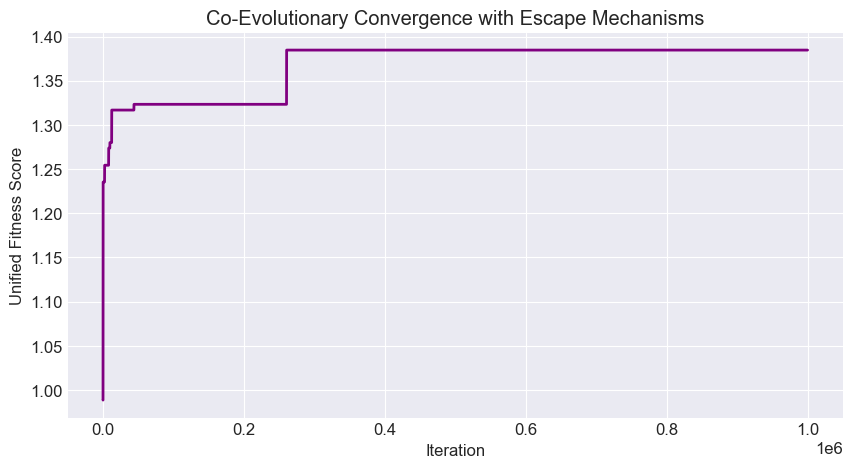

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================================================
# Step 1 & 2: Data Setup & Initialization (คงเดิม)
# =========================================================
target_assets = 30  
min_per_sector = 3

tickers = data.columns.tolist()
num_assets = len(tickers)

ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 
unique_sectors = list(set(ticker_sectors))
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)

# --- Hyperparameters ---
num_iterations = 1_000_000
num_agents = 500 
MAX_WEIGHT = 0.15  # [NEW] จำกัดน้ำหนักสูงสุดที่ 15%



# ANTS Params (แทนที่ ACO Params เดิม)
alpha_ants = 0.5  # น้ำหนักความสำคัญระหว่าง ฟีโรโมน (alpha) และ ฮิวริสติก (1 - alpha)
evaporation_rate = 0.2
Q = 1.0
PHEROMONE_MIN = 0.1
PHEROMONE_MAX = 10.0
pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)

# [NEW] ตัวแปรสำหรับ ANTS Pheromone Update
moving_avg_fitness = 0.0
gamma_ants = 0.9  # น้ำหนักสำหรับคำนวณ Exponential Moving Average

# EBGWO Params
ST = 0.25 
def apply_weight_constraint(w_tensor, max_w=0.25, max_iters=5):
    for _ in range(max_iters):
        # หาผลรวมของน้ำหนักที่เกินขีดจำกัด
        excess = torch.clamp(w_tensor - max_w, min=0.0).sum(dim=1, keepdim=True)
        # ตัดน้ำหนักไม่ให้เกิน max_w
        w_tensor = torch.clamp(w_tensor, 0.0, max_w)
        
        # หาพื้นที่ว่างของสินทรัพย์ที่ยังสามารถรับน้ำหนักเพิ่มได้
        available_space = torch.clamp(max_w - w_tensor, min=0.0)
        space_sum = available_space.sum(dim=1, keepdim=True)
        
        # กระจายน้ำหนักที่เกินไปยังพื้นที่ว่างตามสัดส่วน
        dist_mask = space_sum > 1e-8
        w_tensor = torch.where(dist_mask, w_tensor + excess * (available_space / (space_sum + 1e-8)), w_tensor)
    
    # Normalize ขั้นสุดท้ายเพื่อป้องกัน Error เล็กน้อยจากการปัดเศษทศนิยม
    return w_tensor / w_tensor.sum(dim=1, keepdim=True)

wolves = torch.rand((num_agents, target_assets), dtype=torch.float32, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True) 
wolves = apply_weight_constraint(wolves, MAX_WEIGHT) # [NEW] บังคับเงื่อนไขตอนเริ่มต้น



# กลไกหลบหนี Local Optima
stagnation_counter = 0
patience = 100  

# Tracking
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)
global_best_fitness = -np.inf
global_best_portfolio = None
global_best_weights = None
global_best_sharpe = 0.0
convergence_curve = []

# =========================================================
# Step 3: Co-Evolutionary Loop (Unified Fitness with Escape)
# =========================================================


print("\n--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---")

for iteration in range(num_iterations):
    
    # -----------------------------------------------------
    # 1. ANTS: Asset Selection Phase (Additive Rule)
    # -----------------------------------------------------
    # Normalize ฟีโรโมนและฮิวริสติกให้อยู่ในสเกลเดียวกัน (Sum = 1) ก่อนนำมาบวกกัน
    norm_pheromones = pheromones / pheromones.sum()
    norm_heuristic = heuristic_tensor / heuristic_tensor.sum()
    
    # กฎการเลือกแบบ ANTS (Additive Combination)
    probabilities = (alpha_ants * norm_pheromones) + ((1.0 - alpha_ants) * norm_heuristic)
    probabilities /= probabilities.sum()
    
    probs_batch = probabilities.unsqueeze(0).expand(num_agents, -1)
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    # ... (ส่วนการเลือก Sector แบบ Mandatory และ Remaining คงเดิม) ...
    for sector_idx in range(len(unique_sectors)):
        sector_mask = (sector_labels == sector_idx).float()
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        epsilon = 1e-8
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            selected_s = torch.multinomial(probs_sector, actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_agents, 0), dtype=torch.int64, device=device)

    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        selected_rem = torch.multinomial(probs_remaining, num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1) 
    else:
        selected_indices = selected_mandatory[:, :target_assets]

        
    # -----------------------------------------------------
    # 2. UNIFIED FITNESS CALCULATION
    # -----------------------------------------------------
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    mask = torch.zeros((num_agents, num_assets), device=device)
    mask.scatter_(1, selected_indices, wolves) 
    
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    unified_fitness = portfolio_sharpe * decorrelation_fitness
    
    # -----------------------------------------------------
    # 3. GLOBAL BEST TRACKING & STAGNATION CHECK
    # -----------------------------------------------------
    sorted_indices = torch.argsort(unified_fitness, descending=True)
    best_agent_idx = sorted_indices[0]
    iter_best_fitness = unified_fitness[best_agent_idx].item()
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = selected_indices[best_agent_idx].clone()
        global_best_weights = wolves[best_agent_idx].clone()
        global_best_sharpe = portfolio_sharpe[best_agent_idx].item()
        stagnation_counter = 0  # รีเซ็ตตัวนับเมื่อพบค่าที่ดีกว่า
    else:
        stagnation_counter += 1 # เพิ่มตัวนับเมื่อค่าไม่ดีขึ้น
        
    convergence_curve.append(global_best_fitness)
    
    # -----------------------------------------------------
    # 4. ESCAPE MECHANISM (ทำงานเมื่อติด Local Optima)
    # -----------------------------------------------------
    if stagnation_counter > patience:
            mean_pheromone = pheromones.mean().item()
            pheromones = torch.ones_like(pheromones) * mean_pheromone
            
            num_reset = num_agents // 2
            reset_indices = sorted_indices[-num_reset:]
            new_random_wolves = torch.rand((num_reset, target_assets), dtype=torch.float32, device=device)
            new_random_wolves = new_random_wolves / new_random_wolves.sum(dim=1, keepdim=True)
            
            # [NEW] บังคับเงื่อนไขน้ำหนักตอนรีเซ็ต
            new_random_wolves = apply_weight_constraint(new_random_wolves, MAX_WEIGHT) 
            wolves[reset_indices] = new_random_wolves
            
            stagnation_counter = 0
        # สามารถเปิด Print เพื่อดูว่ามีการกระตุ้นกลไกหลบหนีในรอบไหนบ้าง
            # print(f"Iteration {iteration}: Triggered Local Optima Escape Mechanism!")

    # -----------------------------------------------------
    # 5. UPDATES (ANTS Pheromone Update & EBGWO)
    # -----------------------------------------------------
    
    # [NEW] อัปเดต Moving Average สำหรับ ANTS
    if iteration == 0:
        moving_avg_fitness = iter_best_fitness
    else:
        moving_avg_fitness = (gamma_ants * moving_avg_fitness) + ((1 - gamma_ants) * iter_best_fitness)
        
    # [NEW] คำนวณความแตกต่าง (Reward) โดยเปรียบเทียบกับ Moving Average
    # หากรอบปัจจุบันทำได้ดีกว่าค่าเฉลี่ย จะได้ค่าบวก หากแย่กว่าจะได้ค่าลบ
    relative_reward = (iter_best_fitness - moving_avg_fitness) / (abs(moving_avg_fitness) + 1e-8)

    # Update ANTS Pheromones
    pheromones *= (1 - evaporation_rate)
    
    # ทิ้งฟีโรโมนตามค่า Relative Reward
    pheromones[selected_indices[best_agent_idx]] += Q * relative_reward
    
    # ป้องกันการกระจุกตัวและค่าติดลบ
    pheromones = torch.clamp(pheromones, PHEROMONE_MIN, PHEROMONE_MAX)
    # Update EBGWO
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    # ทำให้ค่า 'a' กระเพื่อมขึ้นลง (Non-linear cyclical) แทนการลดลงเส้นตรง เพื่อรักษาสถานะการสำรวจ
    a = 2.0 * (1.0 - (iteration % (num_iterations // 5)) / (num_iterations // 5)) 
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_agents, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_agents, (num_agents,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    new_wolves = (X1 + X2 + X3) / 3.0
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

    # [NEW] บังคับเงื่อนไขน้ำหนักสูงสุดไม่เกิน 25% สำหรับทุก Agent
    wolves = apply_weight_constraint(wolves, MAX_WEIGHT)


# =========================================================
# Step 4: Output the Best Found Result
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_weights = global_best_weights.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

final_subset_returns = returns_tensor[:, global_best_portfolio]
final_port_returns = torch.matmul(final_subset_returns, global_best_weights)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()
print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': final_weights
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))


print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print("----------------------------------")

# Plotting Combined Convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='', color='purple', linewidth=2)
plt.title('Co-Evolutionary Convergence with Escape Mechanisms')
plt.xlabel('Iteration')
plt.ylabel('Unified Fitness Score')
plt.grid(True)
plt.show()


Executing on: cuda

--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---

--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.3326
Associated Sharpe Ratio: 1.6380
Expected Annualized Return: 55.20%
Expected Annualized Volatility: 31.05%
----------------------------------

Final Optimal Portfolio Weights:
   Ticker          Sector Weight
0     FIX     Industrials 14.82%
1     VRT     Industrials 14.26%
2    VCSH           Bonds 12.93%
3    FUTU  Chinese Stocks  8.01%
4     CEG       Utilities  7.96%
5    AXON     Industrials  6.90%
6    TIPS           Bonds  6.48%
7      DD       Materials  4.92%
8      CB      Financials  4.08%
9     AWK       Utilities  3.25%
10    IVZ      Financials  3.04%
11      O     Real Estate  2.09%
12    ECL       Materials  1.90%
13    NRG       Utilities  1.80%

--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.3326
Associated Sharpe Ratio: 1.6380
----------------------------------


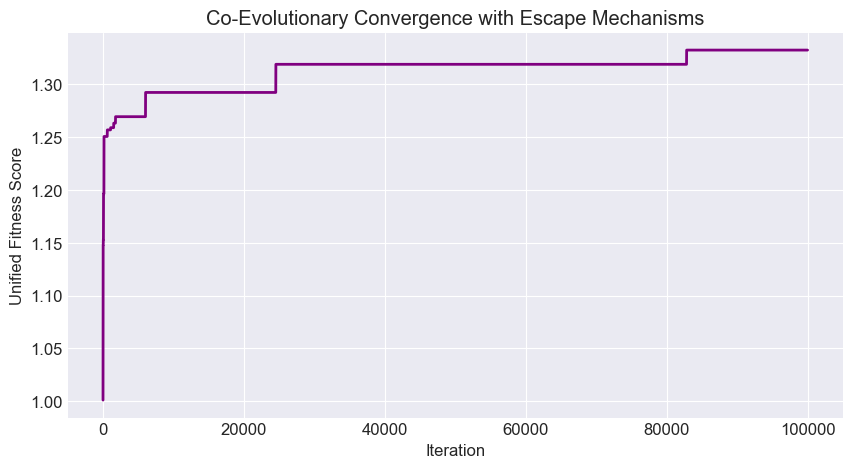

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================================================
# Step 1 & 2: Data Setup & Initialization (คงเดิม)
# =========================================================
target_assets = 30  
min_per_sector = 3

tickers = data.columns.tolist()
num_assets = len(tickers)

ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 
unique_sectors = list(set(ticker_sectors))
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

returns_tensor = torch.tensor(returns.values, dtype=torch.float32, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float32, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float32, device=device)
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)


# --- Hyperparameters ---
num_iterations = 100_000
num_agents = 500 
MAX_WEIGHT = 0.15  

# ANTS Params สำหรับ WIDE SEARCHING
alpha_ants = 0.2  # ลดอิทธิพลฟีโรโมน เน้นกระจายการสุ่ม
evaporation_rate = 0.01  # ฟีโรโมนระเหยช้าลง เก็บเส้นทางสำรองไว้นานขึ้น
Q = 1.0
PHEROMONE_MIN = 0.5
PHEROMONE_MAX = 1.5  # ลดเพดานเพื่อไม่ให้เกิดการผูกขาด
pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)

# ตัวแปรสำหรับ ANTS Pheromone Update
moving_avg_fitness = 0.0
gamma_ants = 0.9  

# EBGWO Params สำหรับ WIDE SEARCHING
ST = 0.6  # เพิ่มโอกาสสุ่มค้นหาตำแหน่งใหม่ให้สูงขึ้นมาก

def apply_weight_constraint(w_tensor, max_w=0.25, max_iters=5):
    for _ in range(max_iters):
        # หาผลรวมของน้ำหนักที่เกินขีดจำกัด
        excess = torch.clamp(w_tensor - max_w, min=0.0).sum(dim=1, keepdim=True)
        # ตัดน้ำหนักไม่ให้เกิน max_w
        w_tensor = torch.clamp(w_tensor, 0.0, max_w)
        
        # หาพื้นที่ว่างของสินทรัพย์ที่ยังสามารถรับน้ำหนักเพิ่มได้
        available_space = torch.clamp(max_w - w_tensor, min=0.0)
        space_sum = available_space.sum(dim=1, keepdim=True)
        
        # กระจายน้ำหนักที่เกินไปยังพื้นที่ว่างตามสัดส่วน
        dist_mask = space_sum > 1e-8
        w_tensor = torch.where(dist_mask, w_tensor + excess * (available_space / (space_sum + 1e-8)), w_tensor)
    
    # Normalize ขั้นสุดท้ายเพื่อป้องกัน Error เล็กน้อยจากการปัดเศษทศนิยม
    return w_tensor / w_tensor.sum(dim=1, keepdim=True)

wolves = torch.rand((num_agents, target_assets), dtype=torch.float32, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True) 
wolves = apply_weight_constraint(wolves, MAX_WEIGHT)

# กลไกหลบหนี Local Optima สำหรับ WIDE SEARCHING
stagnation_counter = 0
patience = 40  # ทนรอแค่ 40 รอบ ถ้าไม่ดีขึ้นให้รีเซ็ตหมาป่าครึ่งฝูงทันที


# Tracking
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float32, device=device)
global_best_fitness = -np.inf
global_best_portfolio = None
global_best_weights = None
global_best_sharpe = 0.0
convergence_curve = []

# =========================================================
# Step 3: Co-Evolutionary Loop (Unified Fitness with Escape)
# =========================================================


print("\n--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---")

for iteration in range(num_iterations):
    
    # -----------------------------------------------------
    # 1. ANTS: Asset Selection Phase (Additive Rule)
    # -----------------------------------------------------
    # Normalize ฟีโรโมนและฮิวริสติกให้อยู่ในสเกลเดียวกัน (Sum = 1) ก่อนนำมาบวกกัน
    norm_pheromones = pheromones / pheromones.sum()
    norm_heuristic = heuristic_tensor / heuristic_tensor.sum()
    
    # กฎการเลือกแบบ ANTS (Additive Combination)
    probabilities = (alpha_ants * norm_pheromones) + ((1.0 - alpha_ants) * norm_heuristic)
    probabilities /= probabilities.sum()
    
    probs_batch = probabilities.unsqueeze(0).expand(num_agents, -1)
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    # ... (ส่วนการเลือก Sector แบบ Mandatory และ Remaining คงเดิม) ...
    for sector_idx in range(len(unique_sectors)):
        sector_mask = (sector_labels == sector_idx).float()
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        epsilon = 1e-8
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            selected_s = torch.multinomial(probs_sector, actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_agents, 0), dtype=torch.int64, device=device)

    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        selected_rem = torch.multinomial(probs_remaining, num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1) 
    else:
        selected_indices = selected_mandatory[:, :target_assets]

        
    # -----------------------------------------------------
    # 2. UNIFIED FITNESS CALCULATION
    # -----------------------------------------------------
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    mask = torch.zeros((num_agents, num_assets), device=device)
    mask.scatter_(1, selected_indices, wolves) 
    
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    unified_fitness = portfolio_sharpe * decorrelation_fitness
    
    # -----------------------------------------------------
    # 3. GLOBAL BEST TRACKING & STAGNATION CHECK
    # -----------------------------------------------------
    sorted_indices = torch.argsort(unified_fitness, descending=True)
    best_agent_idx = sorted_indices[0]
    iter_best_fitness = unified_fitness[best_agent_idx].item()
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = selected_indices[best_agent_idx].clone()
        global_best_weights = wolves[best_agent_idx].clone()
        global_best_sharpe = portfolio_sharpe[best_agent_idx].item()
        stagnation_counter = 0  # รีเซ็ตตัวนับเมื่อพบค่าที่ดีกว่า
    else:
        stagnation_counter += 1 # เพิ่มตัวนับเมื่อค่าไม่ดีขึ้น
        
    convergence_curve.append(global_best_fitness)
    
    # -----------------------------------------------------
    # 4. ESCAPE MECHANISM (ทำงานเมื่อติด Local Optima)
    # -----------------------------------------------------
    if stagnation_counter > patience:
            mean_pheromone = pheromones.mean().item()
            pheromones = torch.ones_like(pheromones) * mean_pheromone
            
            num_reset = num_agents // 2
            reset_indices = sorted_indices[-num_reset:]
            new_random_wolves = torch.rand((num_reset, target_assets), dtype=torch.float32, device=device)
            new_random_wolves = new_random_wolves / new_random_wolves.sum(dim=1, keepdim=True)
            
            # [NEW] บังคับเงื่อนไขน้ำหนักตอนรีเซ็ต
            new_random_wolves = apply_weight_constraint(new_random_wolves, MAX_WEIGHT) 
            wolves[reset_indices] = new_random_wolves
            
            stagnation_counter = 0
        # สามารถเปิด Print เพื่อดูว่ามีการกระตุ้นกลไกหลบหนีในรอบไหนบ้าง
            # print(f"Iteration {iteration}: Triggered Local Optima Escape Mechanism!")

    # -----------------------------------------------------
    # 5. UPDATES (ANTS Pheromone Update & EBGWO)
    # -----------------------------------------------------
    
    # [NEW] อัปเดต Moving Average สำหรับ ANTS
    if iteration == 0:
        moving_avg_fitness = iter_best_fitness
    else:
        moving_avg_fitness = (gamma_ants * moving_avg_fitness) + ((1 - gamma_ants) * iter_best_fitness)
        
    # [NEW] คำนวณความแตกต่าง (Reward) โดยเปรียบเทียบกับ Moving Average
    # หากรอบปัจจุบันทำได้ดีกว่าค่าเฉลี่ย จะได้ค่าบวก หากแย่กว่าจะได้ค่าลบ
    relative_reward = (iter_best_fitness - moving_avg_fitness) / (abs(moving_avg_fitness) + 1e-8)

    # Update ANTS Pheromones
    pheromones *= (1 - evaporation_rate)
    
    # ทิ้งฟีโรโมนตามค่า Relative Reward
    pheromones[selected_indices[best_agent_idx]] += Q * relative_reward
    
    # ป้องกันการกระจุกตัวและค่าติดลบ
    pheromones = torch.clamp(pheromones, PHEROMONE_MIN, PHEROMONE_MAX)
    # Update EBGWO
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    # ทำให้ค่า 'a' กระเพื่อมขึ้นลง (Non-linear cyclical) แทนการลดลงเส้นตรง เพื่อรักษาสถานะการสำรวจ
    a = 2.0 * (1.0 - (iteration % (num_iterations // 5)) / (num_iterations // 5)) 
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_agents, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_agents, (num_agents,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    new_wolves = (X1 + X2 + X3) / 3.0
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

    # [NEW] บังคับเงื่อนไขน้ำหนักสูงสุดไม่เกิน 25% สำหรับทุก Agent
    wolves = apply_weight_constraint(wolves, MAX_WEIGHT)


# =========================================================
# Step 4: Output the Best Found Result
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_weights = global_best_weights.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

final_subset_returns = returns_tensor[:, global_best_portfolio]
final_port_returns = torch.matmul(final_subset_returns, global_best_weights)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()
print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': final_weights
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))


print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print("----------------------------------")

# Plotting Combined Convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='', color='purple', linewidth=2)
plt.title('Co-Evolutionary Convergence with Escape Mechanisms')
plt.xlabel('Iteration')
plt.ylabel('Unified Fitness Score')
plt.grid(True)
plt.show()


Executing on: cuda

--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---

--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.5205
Associated Sharpe Ratio: 1.8506
Expected Annualized Return: 33.18%
Expected Annualized Volatility: 17.93%
----------------------------------

Final Optimal Portfolio Weights:
      Ticker          Sector Weight
0       CBOE      Financials 15.00%
1        HWM     Industrials 14.62%
2        VRT     Industrials  8.92%
3     BBL.BK     Thai Stocks  7.98%
4        EDU  Chinese Stocks  7.29%
5       CHRW     Industrials  6.85%
6        PNW       Utilities  4.72%
7        IEF           Bonds  3.06%
8       TIPS           Bonds  3.05%
9        VST       Utilities  2.75%
10       MUB           Bonds  2.59%
11       TMO     Health Care  2.07%
12  CPALL.BK     Thai Stocks  1.92%
13       CNC     Health Care  1.86%
14       ALL      Financials  1.61%
15        CF       Materials  1.55%
16      VNET  Chinese Stocks  1.42%
17   BTC-USD   

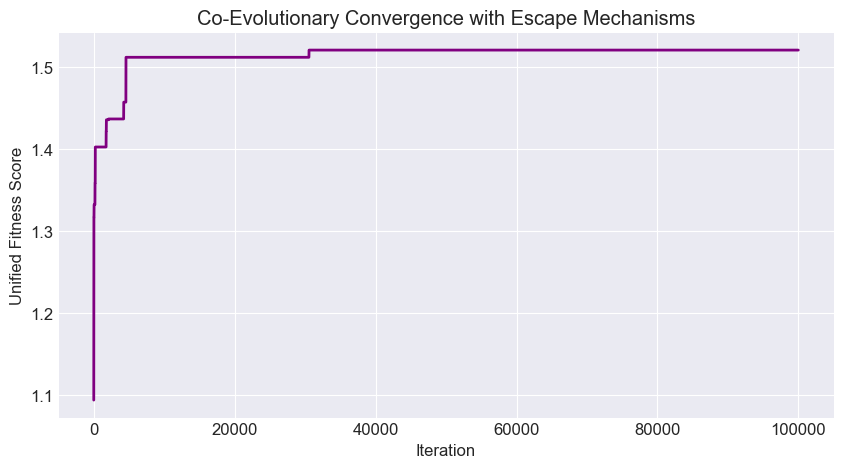

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================================================
# Step 1 & 2: Data Setup & Initialization
# =========================================================
target_assets = 30  
min_per_sector = 3

tickers = data.columns.tolist()
num_assets = len(tickers)

ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 
unique_sectors = list(set(ticker_sectors))
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

# [UPDATED] เปลี่ยนเป็น float16
returns_tensor = torch.tensor(returns.values, dtype=torch.float16, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float16, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float16, device=device)
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)

# --- Hyperparameters ---
num_iterations = 100_000
num_agents = 500 
MAX_WEIGHT = 0.15  

# ANTS Params สำหรับ WIDE SEARCHING
alpha_ants = 0.2  
evaporation_rate = 0.01  
Q = 1.0
PHEROMONE_MIN = 0.5
PHEROMONE_MAX = 1.5  

# [UPDATED] เปลี่ยน Pheromones เป็น 2D Array ขนาด (num_assets, num_assets) และใช้ f16
pheromones = torch.ones((num_assets, num_assets), dtype=torch.float16, device=device)

# ตัวแปรสำหรับ ANTS Pheromone Update
moving_avg_fitness = 0.0
gamma_ants = 0.9  

# EBGWO Params สำหรับ WIDE SEARCHING
ST = 0.6  

def apply_weight_constraint(w_tensor, max_w=0.25, max_iters=5):
    for _ in range(max_iters):
        excess = torch.clamp(w_tensor - max_w, min=0.0).sum(dim=1, keepdim=True)
        w_tensor = torch.clamp(w_tensor, 0.0, max_w)
        
        available_space = torch.clamp(max_w - w_tensor, min=0.0)
        space_sum = available_space.sum(dim=1, keepdim=True)
        
        # [UPDATED] เปลี่ยน 1e-8 เป็น 1e-4 เพื่อป้องกัน underflow ใน f16
        dist_mask = space_sum > 1e-4
        w_tensor = torch.where(dist_mask, w_tensor + excess * (available_space / (space_sum + 1e-4)), w_tensor)
    
    return w_tensor / w_tensor.sum(dim=1, keepdim=True)

# [UPDATED] ใช้ float16 สำหรับ Wolves
wolves = torch.rand((num_agents, target_assets), dtype=torch.float16, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True) 
wolves = apply_weight_constraint(wolves, MAX_WEIGHT)

stagnation_counter = 0
patience = 40  

# Tracking
# [UPDATED] f16 สำหรับ sqrt_252
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float16, device=device)
global_best_fitness = -np.inf
global_best_portfolio = None
global_best_weights = None
global_best_sharpe = 0.0
convergence_curve = []

# =========================================================
# Step 3: Co-Evolutionary Loop (Unified Fitness with Escape)
# =========================================================

print("\n--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---")

for iteration in range(num_iterations):
    
    # -----------------------------------------------------
    # 1. ANTS: Asset Selection Phase (Additive Rule)
    # -----------------------------------------------------
    # [UPDATED] ยุบ 2D Pheromones เป็น 1D โดยหาค่าเฉลี่ยของความสัมพันธ์สำหรับขั้นตอนการเลือก
    agg_pheromones = pheromones.mean(dim=0)
    norm_pheromones = agg_pheromones / agg_pheromones.sum()
    norm_heuristic = heuristic_tensor / heuristic_tensor.sum()
    
    probabilities = (alpha_ants * norm_pheromones) + ((1.0 - alpha_ants) * norm_heuristic)
    probabilities /= probabilities.sum()
    
    probs_batch = probabilities.unsqueeze(0).expand(num_agents, -1)
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    for sector_idx in range(len(unique_sectors)):
        sector_mask = (sector_labels == sector_idx).to(torch.float16)
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        # [UPDATED] f16 stability
        epsilon = 1e-4
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            # [UPDATED] torch.multinomial ต้องการ float32
            selected_s = torch.multinomial(probs_sector.to(torch.float32), actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_agents, 0), dtype=torch.int64, device=device)

    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        selected_rem = torch.multinomial(probs_remaining.to(torch.float32), num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1) 
    else:
        selected_indices = selected_mandatory[:, :target_assets]

        
    # -----------------------------------------------------
    # 2. UNIFIED FITNESS CALCULATION
    # -----------------------------------------------------
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    mask = torch.zeros((num_agents, num_assets), dtype=torch.float16, device=device)
    mask.scatter_(1, selected_indices, wolves) 
    
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # สมมติ RISK_FREE_RATE (เนื่องจากไม่ปรากฏในโค้ดเริ่มต้น)
    RISK_FREE_RATE = 0.0 
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    unified_fitness = portfolio_sharpe * decorrelation_fitness
    
    # -----------------------------------------------------
    # 3. GLOBAL BEST TRACKING & STAGNATION CHECK
    # -----------------------------------------------------
    sorted_indices = torch.argsort(unified_fitness, descending=True)
    best_agent_idx = sorted_indices[0]
    iter_best_fitness = unified_fitness[best_agent_idx].item()
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = selected_indices[best_agent_idx].clone()
        global_best_weights = wolves[best_agent_idx].clone()
        global_best_sharpe = portfolio_sharpe[best_agent_idx].item()
        stagnation_counter = 0 
    else:
        stagnation_counter += 1 
        
    convergence_curve.append(global_best_fitness)
    
    # -----------------------------------------------------
    # 4. ESCAPE MECHANISM 
    # -----------------------------------------------------
    if stagnation_counter > patience:
        mean_pheromone = pheromones.mean().item()
        pheromones = torch.ones_like(pheromones) * mean_pheromone
        
        num_reset = num_agents // 2
        reset_indices = sorted_indices[-num_reset:]
        new_random_wolves = torch.rand((num_reset, target_assets), dtype=torch.float16, device=device)
        new_random_wolves = new_random_wolves / new_random_wolves.sum(dim=1, keepdim=True)
        
        new_random_wolves = apply_weight_constraint(new_random_wolves, MAX_WEIGHT) 
        wolves[reset_indices] = new_random_wolves
        
        stagnation_counter = 0

    # -----------------------------------------------------
    # 5. UPDATES (ANTS Pheromone Update & EBGWO)
    # -----------------------------------------------------
    
    if iteration == 0:
        moving_avg_fitness = iter_best_fitness
    else:
        moving_avg_fitness = (gamma_ants * moving_avg_fitness) + ((1 - gamma_ants) * iter_best_fitness)
        
    # [UPDATED] f16 stability ป้องกันหารด้วยศูนย์
    relative_reward = (iter_best_fitness - moving_avg_fitness) / (abs(moving_avg_fitness) + 1e-4)

    # Update ANTS Pheromones
    pheromones *= (1 - evaporation_rate)
    
    # [UPDATED] อัปเดต Pheromone 2D แบบไขว้ (Pairwise)
    best_indices_1d = selected_indices[best_agent_idx]
    idx_row_update = best_indices_1d.unsqueeze(1) # แนวตั้ง
    idx_col_update = best_indices_1d.unsqueeze(0) # แนวนอน
    
    # ทิ้งฟีโรโมนบนความสัมพันธ์คู่ (Pairwise relationships) ของสินทรัพย์ที่ถูกเลือก
    pheromones[idx_row_update, idx_col_update] += torch.tensor(Q * relative_reward, dtype=torch.float16, device=device)
    
    pheromones = torch.clamp(pheromones, PHEROMONE_MIN, PHEROMONE_MAX)
    
    # Update EBGWO
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    a = 2.0 * (1.0 - (iteration % (num_iterations // 5)) / (num_iterations // 5)) 
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_agents, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_agents, (num_agents,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    new_wolves = (X1 + X2 + X3) / 3.0
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

    wolves = apply_weight_constraint(wolves, MAX_WEIGHT)

# =========================================================
# Step 4: Output the Best Found Result
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_weights = global_best_weights.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

final_subset_returns = returns_tensor[:, global_best_portfolio]
# จำเป็นต้อง cast กลับเพื่อการคูณถ้า returns_tensor มีรูปแบบข้อมูลอื่น แต่ที่นี่เป็น f16 ทั้งคู่
final_port_returns = torch.matmul(final_subset_returns, global_best_weights.unsqueeze(1).to(torch.float16)).squeeze()

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': final_weights
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plotting Combined Convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='', color='purple', linewidth=2)
plt.title('Co-Evolutionary Convergence with Escape Mechanisms')
plt.xlabel('Iteration')
plt.ylabel('Unified Fitness Score')
plt.grid(True)
plt.show()

Executing on: cuda

--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---

--- Co-Evolutionary Optimization Complete ---
Maximized Unified Fitness: 1.5186
Associated Sharpe Ratio: 1.5186
Expected Annualized Return: 53.32%
Expected Annualized Volatility: 32.25%
----------------------------------

Final Optimal Portfolio Weights:
      Ticker                  Sector Weight
0       LITE  Information Technology 10.77%
1        CEG               Utilities  9.46%
2        FIX             Industrials  9.02%
3       TIPS                   Bonds  7.67%
4       PANW  Information Technology  5.25%
5       FSLR  Information Technology  3.31%
6   KBANK.BK             Thai Stocks  2.45%
7        SJM        Consumer Staples  2.39%
8        APD               Materials  1.92%
9        ETR               Utilities  1.83%
10       GSG             Commodities  1.78%
11       TME          Chinese Stocks  1.57%
12       DHI  Consumer Discretionary  1.32%
13    BLA.BK             Thai Stocks  1.30%
14 

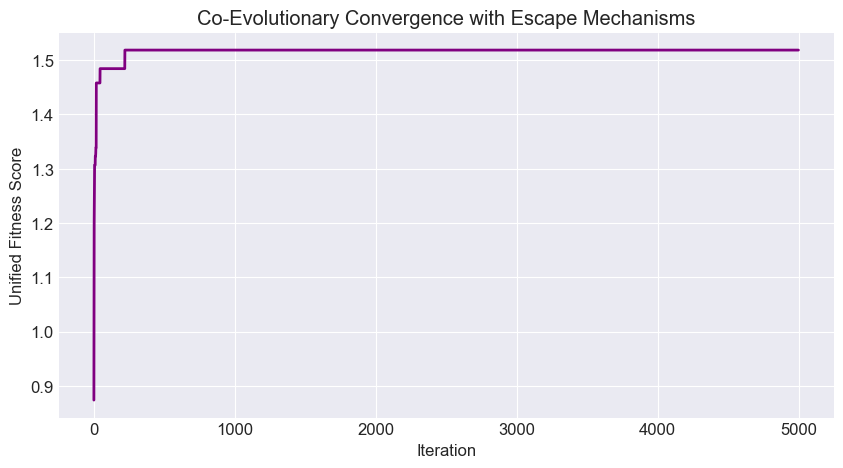

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================================================
# Step 1 & 2: Data Setup & Initialization
# =========================================================
target_assets = 30  
min_per_sector = 1

tickers = data.columns.tolist()
num_assets = len(tickers)

ticker_sectors = [all_sector_map.get(t, 'Unknown') for t in tickers] 
unique_sectors = list(set(ticker_sectors))
sector_to_id = {sector: idx for idx, sector in enumerate(unique_sectors)}
sector_ids = [sector_to_id[s] for s in ticker_sectors]

full_corr_matrix = returns.corr()
avg_asset_corr = (full_corr_matrix.sum(axis=0) - 1) / (num_assets - 1)
heuristic_info = 1.0 - avg_asset_corr
heuristic_info = heuristic_info - heuristic_info.min() + 0.01

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")

# [UPDATED] เปลี่ยนเป็น float16
returns_tensor = torch.tensor(returns.values, dtype=torch.float16, device=device)
full_corr_tensor = torch.tensor(full_corr_matrix.values, dtype=torch.float16, device=device)
heuristic_tensor = torch.tensor(heuristic_info.values, dtype=torch.float16, device=device)
sector_labels = torch.tensor(sector_ids, dtype=torch.int64, device=device)

# --- Hyperparameters ---
num_iterations = 5_000
num_agents = 500 
MAX_WEIGHT = 0.15  

# ANTS Params สำหรับ WIDE SEARCHING
alpha_ants = 0.2  
evaporation_rate = 0.01  
Q = 1.0
PHEROMONE_MIN = 0.5
PHEROMONE_MAX = 1.5  

# [UPDATED] เปลี่ยน Pheromones เป็น 2D Array ขนาด (num_assets, num_assets) และใช้ f16
pheromones = torch.ones((num_assets, num_assets), dtype=torch.float16, device=device)

# ตัวแปรสำหรับ ANTS Pheromone Update
moving_avg_fitness = 0.0
gamma_ants = 0.9  

# EBGWO Params สำหรับ WIDE SEARCHING
ST = 0.6  

def apply_weight_constraint(w_tensor, max_w=0.25, max_iters=5):
    for _ in range(max_iters):
        excess = torch.clamp(w_tensor - max_w, min=0.0).sum(dim=1, keepdim=True)
        w_tensor = torch.clamp(w_tensor, 0.0, max_w)
        
        available_space = torch.clamp(max_w - w_tensor, min=0.0)
        space_sum = available_space.sum(dim=1, keepdim=True)
        
        # [UPDATED] เปลี่ยน 1e-8 เป็น 1e-4 เพื่อป้องกัน underflow ใน f16
        dist_mask = space_sum > 1e-4
        w_tensor = torch.where(dist_mask, w_tensor + excess * (available_space / (space_sum + 1e-4)), w_tensor)
    
    return w_tensor / w_tensor.sum(dim=1, keepdim=True)

# [UPDATED] ใช้ float16 สำหรับ Wolves
wolves = torch.rand((num_agents, target_assets), dtype=torch.float16, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True) 
wolves = apply_weight_constraint(wolves, MAX_WEIGHT)

stagnation_counter = 0
patience = 40  

# Tracking
# [UPDATED] f16 สำหรับ sqrt_252
sqrt_252 = torch.tensor(np.sqrt(252), dtype=torch.float16, device=device)
global_best_fitness = -np.inf
global_best_portfolio = None
global_best_weights = None
global_best_sharpe = 0.0
convergence_curve = []

# =========================================================
# Step 3: Co-Evolutionary Loop (Unified Fitness with Escape)
# =========================================================

print("\n--- Starting Co-Evolutionary Optimization (ANTS + EBGWO) ---")

for iteration in range(num_iterations):
    
    # -----------------------------------------------------
    # 1. ANTS: Asset Selection Phase (Additive Rule)
    # -----------------------------------------------------
    # [UPDATED] ยุบ 2D Pheromones เป็น 1D โดยหาค่าเฉลี่ยของความสัมพันธ์สำหรับขั้นตอนการเลือก
    agg_pheromones = pheromones.mean(dim=0)
    norm_pheromones = agg_pheromones / agg_pheromones.sum()
    norm_heuristic = heuristic_tensor / heuristic_tensor.sum()
    
    probabilities = (alpha_ants * norm_pheromones) + ((1.0 - alpha_ants) * norm_heuristic)
    probabilities /= probabilities.sum()
    
    probs_batch = probabilities.unsqueeze(0).expand(num_agents, -1)
    probs_remaining = probs_batch.clone()
    mandatory_selections = []
    
    for sector_idx in range(len(unique_sectors)):
        sector_mask = (sector_labels == sector_idx).to(torch.float16)
        probs_sector = probs_remaining * sector_mask.unsqueeze(0)
        
        # [UPDATED] f16 stability
        epsilon = 1e-4
        probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
        
        available_in_sector = int(sector_mask.sum().item())
        actual_req = min(min_per_sector, available_in_sector)
        
        if actual_req > 0:
            # [UPDATED] torch.multinomial ต้องการ float32
            selected_s = torch.multinomial(probs_sector.to(torch.float32), actual_req, replacement=False)
            mandatory_selections.append(selected_s)
            probs_remaining.scatter_(1, selected_s, 0.0)
            
    if mandatory_selections:
        selected_mandatory = torch.cat(mandatory_selections, dim=1)
    else:
        selected_mandatory = torch.empty((num_agents, 0), dtype=torch.int64, device=device)

    num_mandatory = selected_mandatory.shape[1]
    num_remaining = target_assets - num_mandatory
    
    if num_remaining > 0:
        selected_rem = torch.multinomial(probs_remaining.to(torch.float32), num_remaining, replacement=False)
        selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1) 
    else:
        selected_indices = selected_mandatory[:, :target_assets]

        
    # -----------------------------------------------------
    # 2. UNIFIED FITNESS CALCULATION
    # -----------------------------------------------------
    idx_row = selected_indices.unsqueeze(2) 
    idx_col = selected_indices.unsqueeze(1) 
    batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
    sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
    avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
    decorrelation_fitness = 1.0 - avg_pairwise_corr
    
    mask = torch.zeros((num_agents, num_assets), dtype=torch.float16, device=device)
    mask.scatter_(1, selected_indices, wolves) 
    
    portfolio_returns = torch.matmul(returns_tensor, mask.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # สมมติ RISK_FREE_RATE (เนื่องจากไม่ปรากฏในโค้ดเริ่มต้น)
    
    portfolio_sharpe = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    unified_fitness = portfolio_sharpe 
    
    # -----------------------------------------------------
    # 3. GLOBAL BEST TRACKING & STAGNATION CHECK
    # -----------------------------------------------------
    sorted_indices = torch.argsort(unified_fitness, descending=True)
    best_agent_idx = sorted_indices[0]
    iter_best_fitness = unified_fitness[best_agent_idx].item()
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = selected_indices[best_agent_idx].clone()
        global_best_weights = wolves[best_agent_idx].clone()
        global_best_sharpe = portfolio_sharpe[best_agent_idx].item()
        stagnation_counter = 0 
    else:
        stagnation_counter += 1 
        
    convergence_curve.append(global_best_fitness)
    
    # -----------------------------------------------------
    # 4. ESCAPE MECHANISM 
    # -----------------------------------------------------
    if stagnation_counter > patience:
        mean_pheromone = pheromones.mean().item()
        pheromones = torch.ones_like(pheromones) * mean_pheromone
        
        num_reset = num_agents // 2
        reset_indices = sorted_indices[-num_reset:]
        new_random_wolves = torch.rand((num_reset, target_assets), dtype=torch.float16, device=device)
        new_random_wolves = new_random_wolves / new_random_wolves.sum(dim=1, keepdim=True)
        
        new_random_wolves = apply_weight_constraint(new_random_wolves, MAX_WEIGHT) 
        wolves[reset_indices] = new_random_wolves
        
        stagnation_counter = 0

    # -----------------------------------------------------
    # 5. UPDATES (ANTS Pheromone Update & EBGWO)
    # -----------------------------------------------------
    
    if iteration == 0:
        moving_avg_fitness = iter_best_fitness
    else:
        moving_avg_fitness = (gamma_ants * moving_avg_fitness) + ((1 - gamma_ants) * iter_best_fitness)
        
    # [UPDATED] f16 stability ป้องกันหารด้วยศูนย์
    relative_reward = (iter_best_fitness - moving_avg_fitness) / (abs(moving_avg_fitness) + 1e-4)

    # Update ANTS Pheromones
    pheromones *= (1 - evaporation_rate)
    
    # [UPDATED] อัปเดต Pheromone 2D แบบไขว้ (Pairwise)
    best_indices_1d = selected_indices[best_agent_idx]
    idx_row_update = best_indices_1d.unsqueeze(1) # แนวตั้ง
    idx_col_update = best_indices_1d.unsqueeze(0) # แนวนอน
    
    # ทิ้งฟีโรโมนบนความสัมพันธ์คู่ (Pairwise relationships) ของสินทรัพย์ที่ถูกเลือก
    pheromones[idx_row_update, idx_col_update] += torch.tensor(Q * relative_reward, dtype=torch.float16, device=device)
    
    pheromones = torch.clamp(pheromones, PHEROMONE_MIN, PHEROMONE_MAX)
    
    # Update EBGWO
    alpha_pos = wolves[sorted_indices[0]].clone()
    beta_pos = wolves[sorted_indices[1]].clone()
    delta_pos = wolves[sorted_indices[2]].clone()
    
    a = 2.0 * (1.0 - (iteration % (num_iterations // 5)) / (num_iterations // 5)) 
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_agents, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_agents, (num_agents,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    new_wolves = (X1 + X2 + X3) / 3.0
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

    wolves = apply_weight_constraint(wolves, MAX_WEIGHT)

# =========================================================
# Step 4: Output the Best Found Result
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_weights = global_best_weights.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

final_subset_returns = returns_tensor[:, global_best_portfolio]
# จำเป็นต้อง cast กลับเพื่อการคูณถ้า returns_tensor มีรูปแบบข้อมูลอื่น แต่ที่นี่เป็น f16 ทั้งคู่
final_port_returns = torch.matmul(final_subset_returns, global_best_weights.unsqueeze(1).to(torch.float16)).squeeze()

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': final_weights
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plotting Combined Convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='', color='purple', linewidth=2)
plt.title('Co-Evolutionary Convergence with Escape Mechanisms')
plt.xlabel('Iteration')
plt.ylabel('Unified Fitness Score')
plt.grid(True)
plt.show()

In [ ]:
print("\n--- Co-Evolutionary Optimization Complete ---")

In [ ]:
iteration

In [ ]:

# =========================================================
# Step 4: Output the Best Found Result
# =========================================================
final_portfolio_indices = global_best_portfolio.cpu().numpy()
final_weights = global_best_weights.cpu().numpy()
final_tickers = [tickers[i] for i in final_portfolio_indices]

final_subset_returns = returns_tensor[:, global_best_portfolio]
final_port_returns = torch.matmul(final_subset_returns, global_best_weights)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()
print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print(f"Expected Annualized Return: {final_ann_return:.2%}")
print(f"Expected Annualized Volatility: {final_ann_vol:.2%}")
print("----------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': final_tickers,
    'Sector': [ticker_sectors[tickers.index(t)] for t in final_tickers],
    'Weight': final_weights
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.01]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights:")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))


print("\n--- Co-Evolutionary Optimization Complete ---")
print(f"Maximized Unified Fitness: {global_best_fitness:.4f}")
print(f"Associated Sharpe Ratio: {global_best_sharpe:.4f}")
print("----------------------------------")

# Plotting Combined Convergence
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, marker='', color='purple', linewidth=2)
plt.title('Co-Evolutionary Convergence with Escape Mechanisms')
plt.xlabel('Iteration')
plt.ylabel('Unified Fitness Score')
plt.grid(True)
plt.show()
